# FarmTech Solutions — Visão computacional | Fase 6

**Grupo:** a definir  
**Integrante 1:** NOME_COMPLETO_1 — RM_A_DEFINIR_1  
**Integrante 2:** NOME_COMPLETO_2 — RM_A_DEFINIR_2

Este notebook implementa as Entregas 1 e 2: YOLOv5 customizada (30 e 60 épocas),
YOLOv5 pré-treinada sem customização e CNN do zero. A demonstração usa **bicicletas
e gatos** para simular identificação de objetos e animais nas instalações de um
cliente. Não fazemos diagnóstico veterinário nem controle de acesso a pessoas.

**Pergunta experimental:** aumentar o número de épocas melhora a detecção no
nosso pequeno dataset? Como o detector adaptado se compara ao modelo padrão e
a uma CNN sem pré-treinamento em identificação por imagem e custo computacional?

Execute as células na ordem. A execução local registrada é preservada nas saídas;
uma nova execução no Colab monta seu Drive e grava os novos artefatos nele.
Os nomes e RMs precisam ser preenchidos antes de enviar à FIAP.

## 1. Ambiente e reprodutibilidade

Usamos o código oficial do **YOLOv5 v7.0**, fixado pelo commit, e PyTorch 2.5.1.
A arquitetura nano reduz o custo do experimento. A dependência de Pillow exige
uma adaptação somente na função de tamanho de texto para renderização; ela é
registrada em `setup_yolo` e não altera a rede nem as métricas.

Use Python 3.11–3.12. No Colab, escolha um ambiente com GPU antes de executar.
A instalação pode exigir reiniciar o ambiente caso PyTorch já tenha sido importado.
Tempos registrados nesta cópia correspondem ao dispositivo informado nas tabelas;
tempos em uma GPU Colab serão diferentes.

In [1]:
import sys, subprocess, importlib.metadata
assert (3, 11) <= sys.version_info[:2] <= (3, 12), "Use Python 3.11 a 3.12."
REQUIREMENTS = ['torch==2.5.1', 'torchvision==0.20.1', 'numpy==1.26.4', 'pandas==3.0.6', 'matplotlib==3.11.2', 'requests==2.34.2', 'Pillow==12.3.0', 'PyYAML==6.0.3', 'scikit-learn==1.9.1', 'seaborn==0.13.2', 'scipy==1.17.1', 'tqdm==4.70.1', 'psutil==7.2.2', 'gitpython==3.2.0', 'thop==0.1.1-2209072238', 'tensorboard==2.21.0', 'ipython==9.17.1', 'tabulate==0.10.0', 'setuptools==80.10.2', 'opencv-python==4.10.0.84']
# Instala somente quando as versões não correspondem ao ambiente registrado.
def compatible_environment():
    try:
        return all(importlib.metadata.version(r.split('==')[0]) == r.split('==')[1]
                   for r in REQUIREMENTS)
    except importlib.metadata.PackageNotFoundError:
        return False
if not compatible_environment():
    subprocess.run([sys.executable, '-m', 'pip', 'install', *REQUIREMENTS], check=True)
print('Python:', sys.version.split()[0])
print('PyTorch:', importlib.metadata.version('torch'))

Python: 3.12.14
PyTorch: 2.5.1


## 2. Google Drive e diretórios

No Colab, o projeto é salvo em `MyDrive/FarmTech_Fase6`. A montagem requer login
do proprietário do Drive. Localmente, usamos a pasta do projeto ao lado deste
notebook. Cache e clone do YOLO são temporários; dataset e resultados persistem.

```
FarmTech_Fase6/
├── dataset/images/{train,val,test}/
├── dataset/labels/{train,val,test}/
├── dataset/manifest.csv
├── dataset/makesense_export.zip
├── results/train/{yolo_30ep,yolo_60ep}/weights/best.pt
├── results/cnn/best_cnn.pt
├── results/evaluation/
└── results/predictions/
```

Treino salva em `runs/train` na configuração padrão do YOLOv5; detecção salva em
`runs/detect`. Neste projeto usamos nomes explícitos em `results/` para identificar
qual experimento gerou cada arquivo e evitar sobrescritas acidentais.

In [2]:
from pathlib import Path
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB:
    drive.mount('/content/drive')
    PROJECT = Path('/content/drive/MyDrive/FarmTech_Fase6')
    CACHE = Path('/content/farmtech_cache')
    REPO = Path('/content/yolov5_fase6')
else:
    candidates = [Path.cwd(), Path.cwd().parent]
    PROJECT = next(p for p in candidates if (p/'src/pipeline.py').exists())
    CACHE = PROJECT.parent.parent/'work/cache'
    REPO = PROJECT.parent.parent/'work/yolov5'
PROJECT.mkdir(parents=True, exist_ok=True)
DATA = PROJECT/'dataset'
RESULTS = PROJECT/'results'
RESULTS.mkdir(parents=True, exist_ok=True)
print('Projeto:', PROJECT)

Projeto: /Users/ryanpablo/Documents/Codex/2026-09-30/files-pasted-by-the-user-introdu/outputs/FarmTech_Fase6


## 3. Implementação comentada

As funções abaixo estão incorporadas ao notebook para que ele seja independente
dos arquivos `.py` no GitHub. No repositório, a mesma implementação está em
`src/pipeline.py`. Cada etapa subsequente chama funções específicas e mostra suas
saídas. Não há geração de métricas fictícias.

In [3]:
"""FarmTech Fase 6: coleta rastreável, validação, YOLOv5 e CNN.

As funções são também incorporadas ao notebook, que funciona sem este arquivo.
"""
from pathlib import Path
from collections import defaultdict
import hashlib
import json
import random
import shutil
import subprocess
import sys
import time
import zipfile

import numpy as np
import pandas as pd
import requests
import yaml
from PIL import Image, ImageDraw

SEED = 42
NAMES = ['bicicleta', 'gato']
COCO_IDS = {2: 0, 17: 1}  # IDs oficiais COCO -> classes locais.
COCO_MODEL_IDS = {1: 0, 15: 1}  # Índices contíguos usados pelo YOLO COCO.
REPO_COMMIT = '915bbf294bb74c859f0b41f1c23bc395014ea679'


def download(url, target):
    """Baixa com timeout/repetição e substitui arquivo só após conclusão."""
    target = Path(target)
    target.parent.mkdir(parents=True, exist_ok=True)
    if target.exists() and target.stat().st_size:
        return target
    for attempt in range(3):
        try:
            with requests.get(url, stream=True, timeout=(20, 120)) as response:
                response.raise_for_status()
                with target.with_suffix(target.suffix + '.part').open('wb') as stream:
                    for chunk in response.iter_content(1024 * 1024):
                        stream.write(chunk)
            target.with_suffix(target.suffix + '.part').replace(target)
            return target
        except requests.RequestException:
            if attempt == 2:
                raise
            time.sleep(2)


def normalized_box(box, width, height):
    """Converte COCO xywh para YOLO cxcywh; recorta coordenadas na imagem."""
    x, y, w, h = box
    x1, y1 = max(0, x), max(0, y)
    x2, y2 = min(width, x + w), min(height, y + h)
    if x2 <= x1 or y2 <= y1:
        raise ValueError('Caixa sem área após recorte.')
    return [(x1 + x2) / (2 * width), (y1 + y2) / (2 * height),
            (x2 - x1) / width, (y2 - y1) / height]


def prepare_dataset(root, cache):
    """Seleciona 40 fotos por classe do COCO val2017, sem classes-alvo mistas.

    val2017 é a origem; train/val/test abaixo são as novas divisões acadêmicas.
    As caixas COCO são pré-anotações, não substituem a etapa Make Sense.
    """
    root, cache = Path(root), Path(cache)
    if (root / 'manifest.csv').exists():
        return audit_dataset(root)
    archive = download('https://s3.amazonaws.com/images.cocodataset.org/annotations/annotations_trainval2017.zip',
                       cache / 'annotations_trainval2017.zip')
    with zipfile.ZipFile(archive) as z:
        coco = json.loads(z.read('annotations/instances_val2017.json'))
    by_image = defaultdict(list)
    for ann in coco['annotations']:
        if ann['category_id'] in COCO_IDS:
            by_image[ann['image_id']].append(ann)
    image_info = {x['id']: x for x in coco['images']}
    rows, seen_hashes = [], set()
    rng = random.Random(SEED)
    for category, class_id in COCO_IDS.items():
        candidates = []
        for image_id, anns in sorted(by_image.items()):
            if {a['category_id'] for a in anns} != {category}:
                continue  # Classificação exige um único rótulo por imagem.
            if any(a.get('iscrowd', 0) for a in anns):
                continue  # Exclui grupos ambíguos.
            info = image_info[image_id]
            if max(a['area'] for a in anns) / (info['width'] * info['height']) < .02:
                continue  # Evita só objetos minúsculos; filtro documentado.
            candidates.append(image_id)
        rng.shuffle(candidates)
        collected = 0
        for image_id in candidates:
            if collected == 40:
                break
            info = image_info[image_id]
            split = 'train' if collected < 32 else 'val' if collected < 36 else 'test'
            filename = f'{image_id:012d}.jpg'
            url = 'https://s3.amazonaws.com/images.cocodataset.org/val2017/' + filename
            image = download(url, root / 'images' / split / filename)
            with Image.open(image) as im:
                im.verify()  # Confirma integridade antes de aceitar a imagem.
            digest = hashlib.sha256(image.read_bytes()).hexdigest()
            if digest in seen_hashes:
                image.unlink()
                continue
            seen_hashes.add(digest)
            lines = []
            for ann in by_image[image_id]:
                box = normalized_box(ann['bbox'], info['width'], info['height'])
                lines.append(str(class_id) + ' ' + ' '.join(f'{v:.8f}' for v in box))
            label = root / 'labels' / split / (image.stem + '.txt')
            label.parent.mkdir(parents=True, exist_ok=True)
            label.write_text('\n'.join(lines) + '\n')
            rows.append(dict(image_id=image_id, filename=filename, split=split,
                             class_id=class_id, classe=NAMES[class_id], sha256=digest,
                             source_url=url, flickr_url=info.get('flickr_url', ''),
                             license_id=info.get('license'), width=info['width'], height=info['height']))
            collected += 1
            print(f'{NAMES[class_id]}: {collected}/40 ({split})', flush=True)
        if collected != 40:
            raise RuntimeError('Não há 40 imagens elegíveis/baixáveis para a classe.')
    pd.DataFrame(rows).to_csv(root / 'manifest.csv', index=False)
    (root / 'coco_licenses.json').write_text(json.dumps(coco['licenses'], indent=2))
    write_data_yaml(root)
    export_annotation_package(root)
    return audit_dataset(root)


def write_data_yaml(root):
    root = Path(root).resolve()
    config = dict(path=str(root), train='images/train', val='images/val', test='images/test',
                  nc=2, names=NAMES)
    (root / 'data.yaml').write_text(yaml.safe_dump(config, allow_unicode=True))


def export_annotation_package(root):
    """Cria arquivo com fotos e pré-anotações para importar no Make Sense."""
    root = Path(root)
    with zipfile.ZipFile(root / 'makesense_import.zip', 'w', zipfile.ZIP_DEFLATED) as z:
        for split in ['train', 'val', 'test']:
            for image in sorted((root / 'images' / split).glob('*.jpg')):
                z.write(image, 'images/' + image.name)
                label = root / 'labels' / split / (image.stem + '.txt')
                z.write(label, 'labels/' + label.name)
        z.writestr('labels/classes.txt', '\n'.join(NAMES))
        z.writestr('labels/labels.txt', '\n'.join(NAMES))  # Definição exigida pelo Make Sense.


def import_makesense(root, zip_path):
    """Importa YOLO exportado pelo Make Sense, validando antes de substituir."""
    root = Path(root)
    manifest = pd.read_csv(root / 'manifest.csv')
    required = {Path(f).stem for f in manifest.filename}
    with zipfile.ZipFile(zip_path) as z:
        labels = {Path(n).stem: z.read(n).decode('utf-8-sig') for n in z.namelist()
                  if n.endswith('.txt') and Path(n).stem in required}
    missing = required - labels.keys()
    if missing:
        raise ValueError(f'Exportação incompleta: faltam {len(missing)} rótulos. Revise as 80 imagens.')
    for row in manifest.itertuples():
        validate_label(labels[Path(row.filename).stem], row.class_id)
    backup = root / 'labels_coco_original'
    if not backup.exists():
        shutil.copytree(root / 'labels', backup)
    for row in manifest.itertuples():
        (root / 'labels' / row.split / (Path(row.filename).stem + '.txt')).write_text(
            labels[Path(row.filename).stem])
    for cached in root.rglob('*.cache'):
        cached.unlink()
    (root / 'makesense_export.zip').write_bytes(Path(zip_path).read_bytes())
    (root / 'annotation_status.json').write_text(json.dumps({
        'source': 'Make Sense AI export', 'export_sha256': hashlib.sha256(Path(zip_path).read_bytes()).hexdigest(),
        'images': 80, 'class_order': NAMES}, indent=2))
    return audit_dataset(root)


def validate_label(text, expected_class):
    lines = [l.split() for l in text.splitlines() if l.strip()]
    if not lines:
        raise ValueError('Imagem positiva sem caixa anotada.')
    for line in lines:
        if len(line) != 5:
            raise ValueError('YOLO exige cinco campos, sem coluna de confiança.')
        values = np.asarray([float(x) for x in line])
        c, x, y, w, h = values
        if not np.isfinite(values).all() or c != int(expected_class):
            raise ValueError('Classe incorreta ou valores não finitos.')
        if not (0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1):
            raise ValueError('Coordenadas YOLO fora dos limites.')
        if min(x-w/2, y-h/2) < -1e-5 or max(x+w/2, y+h/2) > 1+1e-5:
            raise ValueError('Caixa ultrapassa a imagem.')


def audit_dataset(root):
    root = Path(root)
    df = pd.read_csv(root / 'manifest.csv')
    assert len(df) == 80 and df.image_id.nunique() == 80 and df.sha256.nunique() == 80
    expected = {'train': 32, 'val': 4, 'test': 4}
    for class_id in [0, 1]:
        for split, count in expected.items():
            assert len(df[(df.class_id == class_id) & (df.split == split)]) == count
    for row in df.itertuples():
        image = root / 'images' / row.split / row.filename
        assert hashlib.sha256(image.read_bytes()).hexdigest() == row.sha256
        validate_label((root / 'labels' / row.split / (image.stem + '.txt')).read_text(), row.class_id)
    write_data_yaml(root)  # Corrige caminhos absolutos após cópia para o Drive.
    print('Auditoria: 80 imagens íntegras, divisão 64/8/8 e nenhuma duplicata exata.')
    return df.groupby(['classe', 'split']).size().unstack().reindex(columns=['train', 'val', 'test'])


def show_samples(root, output):
    """Gera evidência com caixas de referência, sem chamar isso de predição."""
    root, output = Path(root), Path(output)
    df = pd.read_csv(root / 'manifest.csv')
    rows = df.groupby(['class_id', 'split'], sort=True).head(1)
    canvas = Image.new('RGB', (1080, 720), '#101827')
    draw = ImageDraw.Draw(canvas)
    for i, row in enumerate(rows.itertuples()):
        im = Image.open(root / 'images' / row.split / row.filename).convert('RGB')
        d = ImageDraw.Draw(im)
        for line in (root / 'labels' / row.split / (Path(row.filename).stem + '.txt')).read_text().splitlines():
            c, x, y, w, h = map(float, line.split())
            box = ((x-w/2)*im.width, (y-h/2)*im.height, (x+w/2)*im.width, (y+h/2)*im.height)
            d.rectangle(box, outline='#2fe6a8', width=4)
        im.thumbnail((344, 294))
        px, py = (i % 3) * 360 + 8, (i // 3) * 360 + 44
        canvas.paste(im, (px, py))
        draw.text((px, py - 28), f'{row.classe} | {row.split} | {row.image_id}', fill='white')
    output.parent.mkdir(parents=True, exist_ok=True)
    canvas.save(output)
    return output


def setup_yolo(repo):
    repo = Path(repo).resolve()
    if not repo.exists():
        subprocess.run(['git', 'clone', '--depth', '1', '--branch', 'v7.0',
                        'https://github.com/ultralytics/yolov5.git', str(repo)], check=True)
    revision = subprocess.check_output(['git', '-C', str(repo), 'rev-parse', 'HEAD'], text=True).strip()
    assert revision == REPO_COMMIT, 'Revisão YOLOv5 diferente da fixada.'
    download('https://github.com/ultralytics/yolov5/releases/download/v7.0/yolov5n.pt', repo / 'yolov5n.pt')
    # Compatibilidade de renderização: Pillow >=10 removeu getsize().
    plots = repo / 'utils/plots.py'
    source = plots.read_text()
    for value in ['label', 'text']:
        source = source.replace(f'self.font.getsize({value})',
            f'(self.font.getbbox({value})[2], self.font.getbbox({value})[3])')
    plots.write_text(source)
    return repo


def train_yolo(root, repo, results, epochs, device='cpu', imgsz=224):
    """Duas execuções independentes partem do MESMO checkpoint pré-treinado."""
    root, repo, results = map(lambda p: Path(p).resolve(), [root, repo, results])
    name = f'yolo_{epochs}ep'
    run = results / 'train' / name
    if (run / 'execution.json').exists():
        meta = json.loads((run / 'execution.json').read_text())
        meta['weights'] = str(run / 'weights/best.pt')
        previous = pd.read_csv(run / 'results.csv')
        previous.columns = previous.columns.str.strip()
        meta['best_epoch'] = int((.1*previous['metrics/mAP_0.5']+.9*previous['metrics/mAP_0.5:0.95']).idxmax())+1
        return meta
    if run.exists():
        raise RuntimeError(f'Execução parcial em {run}; renomeie para preservá-la antes de repetir.')
    results.mkdir(parents=True, exist_ok=True)
    cmd = [sys.executable, str(repo / 'train.py'), '--data', str(root / 'data.yaml'),
           '--weights', str(repo / 'yolov5n.pt'), '--epochs', str(epochs), '--imgsz', str(imgsz),
           '--batch-size', '4', '--workers', '0', '--device', device, '--seed', str(SEED),
           '--patience', str(epochs+1), '--project', str(results / 'train'), '--name', name,
           '--exist-ok']
    started = time.perf_counter()
    with (results / f'{name}.log').open('w') as log:
        process = subprocess.Popen(cmd, cwd=repo, stdout=log, stderr=subprocess.STDOUT)
        while process.poll() is None:
            time.sleep(10)
            csv = run / 'results.csv'
            completed = len(pd.read_csv(csv)) if csv.exists() else 0
            print(f'{name}: {completed}/{epochs} épocas registradas', flush=True)
        if process.returncode:
            raise RuntimeError(f'Treino falhou. Consulte {log.name}.')
    history = pd.read_csv(run / 'results.csv')
    history.columns = history.columns.str.strip()
    assert len(history) == epochs, 'Treino não completou a quantidade solicitada de épocas.'
    meta = dict(model=name, epochs=epochs, train_seconds=time.perf_counter()-started,
                weights=str(run / 'weights/best.pt'), device=device, imgsz=imgsz,
                seed=SEED, repo_commit=REPO_COMMIT,
                best_epoch=int((.1*history['metrics/mAP_0.5']+.9*history['metrics/mAP_0.5:0.95']).idxmax())+1)
    (run / 'execution.json').write_text(json.dumps(meta, indent=2))
    return meta


def initialize_yolo_imports(repo):
    repo = str(Path(repo).resolve())
    if repo not in sys.path:
        sys.path.insert(0, repo)
    import torch
    torch.set_num_threads(4)


def evaluate_detection(root, repo, results, weights, name, split, standard=False, device='cpu'):
    """mAP com caixas reais. Baseline usa rótulos remapeados para 80 classes."""
    initialize_yolo_imports(repo)
    from val import run
    root, results = Path(root).resolve(), Path(results).resolve()
    data = root / 'data.yaml'
    if standard:
        target = root / 'baseline_coco'
        for s in ['train', 'val', 'test']:
            (target / 'images' / s).mkdir(parents=True, exist_ok=True)
            (target / 'labels' / s).mkdir(parents=True, exist_ok=True)
            for image in (root / 'images' / s).glob('*.jpg'):
                if not (target / 'images' / s / image.name).exists():
                    shutil.copy2(image, target / 'images' / s / image.name)
                label = root / 'labels' / s / (image.stem+'.txt')
                lines = []
                for line in label.read_text().splitlines():
                    parts = line.split()
                    parts[0] = str({0: 1, 1: 15}[int(parts[0])])
                    lines.append(' '.join(parts))
                (target / 'labels' / s / label.name).write_text('\n'.join(lines)+'\n')
        for p in target.rglob('*.cache'):
            p.unlink()
        original = yaml.safe_load((Path(repo) / 'data/coco.yaml').read_text())
        config = dict(path=str(target), train='images/train', val='images/val', test='images/test',
                      nc=80, names=original['names'])
        data = target / 'data.yaml'
        data.write_text(yaml.safe_dump(config))
    metrics, maps, speed = run(data=str(data), weights=str(weights), imgsz=224, batch_size=4,
                              task=split, device=device, workers=0, half=False,
                              project=str(results / 'evaluation'), name=f'{name}_{split}',
                              exist_ok=True, plots=True)
    # val.py retorna P, R, mAP50, mAP50-95 e três losses (zeros fora do treino).
    p, r, map50, map95 = map(float, metrics[:4])
    record = dict(model=name, split=split, precision=p, recall=r, map50=map50, map50_95=map95,
                  inference_forward_ms=float(speed[1]),
                  annotation_source='Make Sense AI' if (root/'annotation_status.json').exists() else 'COCO (pré-anotação)')
    out = results / 'evaluation' / f'{name}_{split}' / 'metrics.json'
    out.write_text(json.dumps(record, indent=2))
    return record


def yolo_image_predictions(root, repo, weights, standard=False, device='cpu', split='test'):
    """Classificação derivada: classe da caixa mais confiante; sem caixa = abstenção."""
    initialize_yolo_imports(repo)
    import torch
    from models.common import AutoShape, DetectMultiBackend
    backend = DetectMultiBackend(str(weights), device=torch.device(device))
    model = AutoShape(backend, verbose=False)
    model.conf = .25
    model.iou = .45
    # Mantém apenas as classes-alvo no baseline para não contar outras classes COCO.
    model.classes = [1, 15] if standard else [0, 1]
    df = pd.read_csv(Path(root) / 'manifest.csv')
    selected = df[df.split == split]
    for row in selected.head(2).itertuples():
        model(Image.open(Path(root)/'images'/split/row.filename).convert('RGB'), size=224)
    records, images = [], []
    for row in selected.itertuples():
        im = Image.open(Path(root)/'images'/split/row.filename).convert('RGB')
        times = []
        for _ in range(3):
            if device == 'mps':
                torch.mps.synchronize()
            elif device.startswith('cuda'):
                torch.cuda.synchronize()
            start = time.perf_counter()
            prediction = model(im, size=224)
            boxes = prediction.xyxy[0].cpu().numpy()
            predicted, confidence = -1, 0.0
            if len(boxes):
                best = boxes[np.argmax(boxes[:, 4])]
                predicted = COCO_MODEL_IDS[int(best[5])] if standard else int(best[5])
                confidence = float(best[4])
            if device == 'mps':
                torch.mps.synchronize()
            elif device.startswith('cuda'):
                torch.cuda.synchronize()
            times.append((time.perf_counter()-start)*1000)
        records.append(dict(filename=row.filename, true=int(row.class_id), predicted=predicted,
                            confidence=confidence, latency_ms=float(np.median(times))))
        annotated = im.copy()
        draw = ImageDraw.Draw(annotated)
        for x1, y1, x2, y2, conf, cls in boxes:
            c = COCO_MODEL_IDS[int(cls)] if standard else int(cls)
            draw.rectangle((x1,y1,x2,y2), outline='#16d99e', width=4)
            draw.text((x1, max(0,y1-15)), f'{NAMES[c]} {conf:.2f}', fill='#16d99e')
        images.append((row.filename, annotated))
    return records, images


def classification_metrics(records, model_name):
    """Abstenções são erros; matriz 2 x 3 inclui a coluna sem detecção."""
    from sklearn.metrics import accuracy_score, f1_score
    truth = [r['true'] for r in records]
    pred = [r['predicted'] for r in records]
    cm = np.zeros((2,3), dtype=int)
    for a,b in zip(truth,pred):
        cm[a, b if b >= 0 else 2] += 1
    return dict(model=model_name, accuracy=accuracy_score(truth,pred),
                error_rate=1-accuracy_score(truth,pred),
                macro_f1=f1_score(truth,pred,labels=[0,1],average='macro',zero_division=0),
                abstentions=sum(p == -1 for p in pred),
                latency_median_ms=float(np.median([r['latency_ms'] for r in records])),
                n_images=len(records), confusion_matrix=cm.tolist())


def make_cnn():
    """CNN pequena inicializada aleatoriamente, sem pesos pré-treinados."""
    import torch.nn as nn
    return nn.Sequential(nn.Conv2d(3,16,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
                         nn.Conv2d(16,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
                         nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
                         nn.AdaptiveAvgPool2d((4,4)), nn.Flatten(), nn.Dropout(.3),
                         nn.Linear(64*4*4,64), nn.ReLU(), nn.Linear(64,2))


def image_loader(root, split, training=False, batch_size=8):
    import torch
    from torchvision import transforms
    from torch.utils.data import Dataset, DataLoader
    class Photos(Dataset):
        def __init__(self):
            df = pd.read_csv(Path(root)/'manifest.csv')
            self.rows = list(df[df.split==split].itertuples())
            operations = [transforms.Resize((160,160))]
            if training:
                operations += [transforms.RandomHorizontalFlip(), transforms.ColorJitter(.15,.15,.15,.05)]
            self.transform = transforms.Compose(operations+[transforms.ToTensor(),
                transforms.Normalize([.5]*3,[.5]*3)])
        def __len__(self):
            return len(self.rows)
        def __getitem__(self,i):
            row = self.rows[i]
            im = Image.open(Path(root)/'images'/split/row.filename).convert('RGB')
            return self.transform(im), int(row.class_id), row.filename
    return DataLoader(Photos(), batch_size=batch_size, shuffle=training, num_workers=0,
                      generator=torch.Generator().manual_seed(SEED))


def train_cnn(root, results, epochs=60, device='cpu'):
    import torch
    import torch.nn as nn
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.set_num_threads(4)
    model = make_cnn().to(device)
    optimizer = torch.optim.Adam(model.parameters(),lr=.001,weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    output = Path(results)/'cnn'
    output.mkdir(parents=True,exist_ok=True)
    if (output/'execution.json').exists() and (output/'best_cnn.pt').exists():
        return json.loads((output/'execution.json').read_text())
    train, val = image_loader(root,'train',True), image_loader(root,'val')
    history, best = [], float('inf')
    started = time.perf_counter()
    for epoch in range(epochs):
        metrics = {}
        for split, loader in [('train',train),('val',val)]:
            model.train(split=='train')
            loss_total, hits, n = 0.,0,0
            with torch.set_grad_enabled(split=='train'):
                for x,y,_ in loader:
                    x,y = x.to(device),y.to(device)
                    logits = model(x)
                    loss = criterion(logits,y)
                    if split=='train':
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()
                    loss_total += loss.item()*len(y)
                    hits += int((logits.argmax(1)==y).sum())
                    n += len(y)
            metrics[f'{split}_loss'] = loss_total/n
            metrics[f'{split}_accuracy'] = hits/n
        history.append(dict(epoch=epoch+1,**metrics))
        if metrics['val_loss'] < best:
            best = metrics['val_loss']
            torch.save(model.state_dict(),output/'best_cnn.pt')
        if (epoch+1)%10 == 0:
            print(f'CNN {epoch+1}/{epochs} | val_loss={metrics["val_loss"]:.4f}',flush=True)
    pd.DataFrame(history).to_csv(output/'history.csv',index=False)
    meta = dict(model='cnn_zero',epochs=epochs,train_seconds=time.perf_counter()-started,device=device,
                best_epoch=int(pd.DataFrame(history).val_loss.idxmin())+1)
    (output/'execution.json').write_text(json.dumps(meta,indent=2))
    return meta


def cnn_predictions(root, results, device='cpu', split='test'):
    import torch
    model = make_cnn().to(device)
    model.load_state_dict(torch.load(Path(results)/'cnn/best_cnn.pt',map_location=device,weights_only=True))
    model.eval()
    loader = image_loader(root,split,batch_size=1)
    records = []
    with torch.inference_mode():
        for _ in range(2):
            model(next(iter(loader))[0].to(device))
        for x,y,filenames in loader:
            times = []
            # Mesmo protocolo: input RGB decodificado -> pré-processamento -> decisão.
            for _ in range(3):
                from torchvision import transforms
                original = Image.open(Path(root)/'images'/split/filenames[0]).convert('RGB')
                transform = transforms.Compose([transforms.Resize((160,160)),transforms.ToTensor(),
                                                 transforms.Normalize([.5]*3,[.5]*3)])
                if device == 'mps':
                    torch.mps.synchronize()
                elif device.startswith('cuda'):
                    torch.cuda.synchronize()
                started = time.perf_counter()
                logits = model(transform(original).unsqueeze(0).to(device))
                probabilities = logits.softmax(1)
                confidence,pred = probabilities.max(1)
                confidence,pred = float(confidence.item()),int(pred.item())
                if device == 'mps':
                    torch.mps.synchronize()
                elif device.startswith('cuda'):
                    torch.cuda.synchronize()
                times.append((time.perf_counter()-started)*1000)
            records.append(dict(filename=filenames[0],true=int(y.item()),predicted=pred,
                                confidence=confidence,latency_ms=float(np.median(times))))
    return records


def save_evidence(results, name, records, images=None):
    output = Path(results)/'predictions'/name
    output.mkdir(parents=True,exist_ok=True)
    pd.DataFrame(records).to_csv(output/'predictions.csv',index=False)
    if images:
        for filename, image in images:
            image.save(output/filename)
    metric = classification_metrics(records,name)
    (output/'metrics.json').write_text(json.dumps(metric,indent=2))
    return metric


def create_report(results, detection_records, classification_records, training_records):
    """Relatório só usa resultados calculados; não pressupõe melhoria com mais épocas."""
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    results = Path(results)
    det, cls, training = map(pd.DataFrame,[detection_records,classification_records,training_records])
    det.to_csv(results/'detection_comparison.csv',index=False)
    cls.drop(columns=['confusion_matrix']).to_csv(results/'classification_comparison.csv',index=False)
    training.to_csv(results/'training_comparison.csv',index=False)
    validation = det[(det.split=='val') & det.model.isin(['yolo_30ep', 'yolo_60ep'])]
    winner = validation.sort_values(['map50_95','model'],ascending=[False,True]).iloc[0]['model']
    fig, axes = plt.subplots(1,3,figsize=(15,4))
    for epochs in [30,60]:
        history = pd.read_csv(results/f'train/yolo_{epochs}ep/results.csv')
        history.columns = history.columns.str.strip()
        axes[0].plot(np.arange(1,len(history)+1),history['metrics/mAP_0.5:0.95'],label=f'{epochs} épocas')
        total_loss = history['val/box_loss']+history['val/obj_loss']+history['val/cls_loss']
        axes[1].plot(np.arange(1,len(history)+1),total_loss,label=f'{epochs} épocas')
    axes[0].set(title='mAP50–95 na validação',xlabel='Época',ylim=(0,1))
    axes[1].set(title='Soma das perdas na validação',xlabel='Época')
    axes[2].bar(cls.model,cls.accuracy,color=['#238f77','#44ad9c','#4865bd','#d58a41'])
    axes[2].set(title='Acurácia por imagem (teste)',ylim=(0,1))
    axes[2].tick_params(axis='x',rotation=25)
    for ax in axes[:2]:
        ax.legend()
    fig.tight_layout()
    fig.savefig(results/'comparison.png',dpi=180)
    plt.close(fig)
    fig,axes = plt.subplots(1,len(cls),figsize=(16,4))
    for ax,row in zip(axes,cls.itertuples()):
        matrix = np.asarray(row.confusion_matrix)
        ax.imshow(matrix,cmap='Blues',vmin=0,vmax=4)
        ax.set_xticks(range(3),NAMES+['sem detecção'],rotation=30)
        ax.set_yticks(range(2),NAMES)
        ax.set(title=row.model,xlabel='Predita',ylabel='Real')
        for i in range(2):
            for j in range(3):
                ax.text(j,i,str(matrix[i,j]),ha='center',va='center')
    fig.tight_layout()
    fig.savefig(results/'confusion_matrices.png',dpi=180)
    plt.close(fig)
    d30 = validation[validation.model=='yolo_30ep'].iloc[0]
    d60 = validation[validation.model=='yolo_60ep'].iloc[0]
    delta = d60.map50_95-d30.map50_95
    note = 'aumentou' if delta>0 else 'diminuiu' if delta<0 else 'não alterou'
    test = det[det.split=='test'].set_index('model')
    scores = cls.set_index('model')
    report = f'''# Resultados da execução — FarmTech Fase 6

## Protocolo
80 imagens: 40 bicicletas e 40 gatos; 64 treino, 8 validação e 8 teste.
YOLOv5n v7.0: duas inicializações iguais, 30 e 60 épocas, imagens 224 px,
batch 4 e semente 42. CNN do zero: 60 épocas, imagens 160 px.
Seleção dos pesos por validação. O teste é usado apenas para avaliação final.

## Detecção
{det.round(4).to_markdown(index=False)}

A passagem de 30 para 60 épocas **{note}** a mAP50–95 de validação
em {delta:+.4f}. A configuração selecionada pela validação é **{winner}**.
Mais épocas não garantem desempenho melhor: compare as curvas de perda,
o pico da mAP e a época do checkpoint escolhido. Perdas de box/obj/cls
são acompanhadas no treino; não são percentuais de erro e não são
comparáveis diretamente à entropia cruzada da CNN.

No teste, a YOLO padrão obteve mAP50–95 **{test.loc['yolo_padrao','map50_95']:.4f}**,
enquanto a configuração customizada selecionada obteve
**{test.loc[winner,'map50_95']:.4f}**. Nesta amostra, customizar a rede
não assegurou melhor localização do que utilizar pesos padrão. O detector pode
acertar a classe da foto e, ainda assim, perder instâncias ou detectar caixas falsas.

## Classificação comum às abordagens
{cls.drop(columns=['confusion_matrix']).round(4).to_markdown(index=False)}

O detector recebe como predição da imagem a classe da caixa mais confiante
entre as duas classes-alvo, com confiança mínima 0,25. Ausência de caixa
é abstenção, contada como erro. A CNN fornece diretamente uma das duas classes.
Esta comparação avalia a identificação por imagem; somente YOLO localiza objetos.

A CNN acertou **{round(scores.loc['cnn_zero','accuracy']*8)}/8** imagens;
o detector customizado escolhido acertou **{round(scores.loc[winner,'accuracy']*8)}/8**.
O treino de 30 épocas teve **{int(scores.loc['yolo_30ep','abstentions'])} abstenções**
com limiar 0,25. A mAP usa confiança mínima 0,001 para construir a curva PR;
portanto uma mAP acima de zero pode coexistir com várias abstenções no limiar
operacional. Mantivemos 0,25 fixo, sem ajustá-lo depois de observar o teste.

## Custo de treinamento
{training[['model','epochs','train_seconds','device','best_epoch']].round(3).to_markdown(index=False)}

O baseline pré-treinado não é customizado: seu custo de treinamento **neste projeto**
é zero, mas isso não representa o custo de seu pré-treinamento original.
Latência foi medida após aquecimento, com lote 1, três repetições por imagem,
no mesmo dispositivo, incluindo pré-processamento, decisão e NMS quando aplicável.
Decodificação do arquivo e carregamento dos pesos ficam fora desse intervalo.
As resoluções de entrada diferem (224/160 px), portanto a comparação representa
as configurações implantadas, não a eficiência intrínseca de cada arquitetura.
Os detectores de 30/60 épocas têm a mesma arquitetura: diferenças de latência
podem refletir o número de propostas após NMS, cache e carga concorrente do
computador. Três repetições por foto são poucas; as medições não constituem
benchmark dedicado e não justificam afirmar superioridade geral de velocidade.

## Integração e limitações
YOLO padrão exige pouco esforço quando as classes já existem no COCO; a versão
customizada acrescenta coleta, revisão de caixas e treino, mas adapta a detecção
ao escopo do cliente. A CNN tem arquitetura simples e pipeline de rótulo por imagem,
porém exige implementar treino e pré-processamento e não produz caixas.
Somente 8 imagens de teste: cada acerto altera a acurácia em 12,5 pontos percentuais.
Não há evidência suficiente para afirmar superioridade geral ou uso em produção.
O filtro de tamanho e a exclusão de imagens com ambas as classes tornam o cenário
mais simples; não avaliamos cenas mistas, negativos, vídeos ou mudança de domínio.
As imagens vêm de COCO val2017, benchmark conhecido; checkpoints pré-treinados
podem ter sido selecionados usando esse benchmark. Não tratamos esse teste como
avaliação externa totalmente independente. A CNN do zero não tem esse pré-treino.
Hashes detectam cópias exatas, mas não garantem ausência de cenas semelhantes.
Para o cliente, ampliar a base com fotos próprias, dividir por local/sessão e
avaliar negativos e cenas mistas é o próximo passo antes de implantação.

## Evidências
`comparison.png`, `confusion_matrices.png`, `predictions/` (as oito imagens por
detector), CSVs de resultados, logs, históricos e checkpoints registram a execução.
Fonte das anotações aparece explicitamente na tabela de detecção.
'''
    (results/'RELATORIO_RESULTADOS.md').write_text(report)
    (results/'selection.json').write_text(json.dumps(dict(selected_model=winner,criterion='validation mAP50-95'),indent=2))
    return report


## 4. Coleta e divisão do dataset

Fonte: **COCO 2017**, usando imagens de `val2017`. Esse nome indica a divisão na
base de origem; fazemos uma nova divisão acadêmica, distinta, com semente 42:

| Classe | Treino | Validação | Teste | Total |
|---|---:|---:|---:|---:|
| bicicleta (ID local 0) | 32 | 4 | 4 | 40 |
| gato (ID local 1) | 32 | 4 | 4 | 40 |
| **Total** | **64** | **8** | **8** | **80** |

Selecionamos fotos com apenas uma das duas classes-alvo, sem marcação `iscrowd`
e com pelo menos um objeto ocupando 2% da área. Outros objetos podem aparecer.
Todas as instâncias da classe-alvo são anotadas. A escolha simplifica a tarefa de
classificação; sua limitação é discutida na conclusão. O manifesto registra URL,
ID, licença e hash SHA-256 de cada imagem. Fotos COCO têm licenças individuais;
preservamos suas referências em `coco_licenses.json` e `manifest.csv`.

O download de anotações é cerca de 241 MB, mas baixamos somente as 80 fotos.
O endpoint S3 corresponde ao armazenamento público de imagens COCO e evita
problemas de certificado do domínio de imagens.

**Limitação de independência:** o baseline foi treinado no COCO; a divisão val2017
é um benchmark conhecido e pode ter influenciado a seleção dos pesos originais.
Assim, o experimento não comprova generalização para fotos próprias de uma fazenda.

Auditoria: 80 imagens íntegras, divisão 64/8/8 e nenhuma duplicata exata.


split,train,val,test
classe,,,
bicicleta,32,4,4
gato,32,4,4


,filename,classe,split,license_id
0,000000274687.jpg,bicicleta,train,5
1,000000224051.jpg,bicicleta,train,2
2,000000492937.jpg,bicicleta,train,3
3,000000076547.jpg,bicicleta,train,4
4,000000174482.jpg,bicicleta,train,6


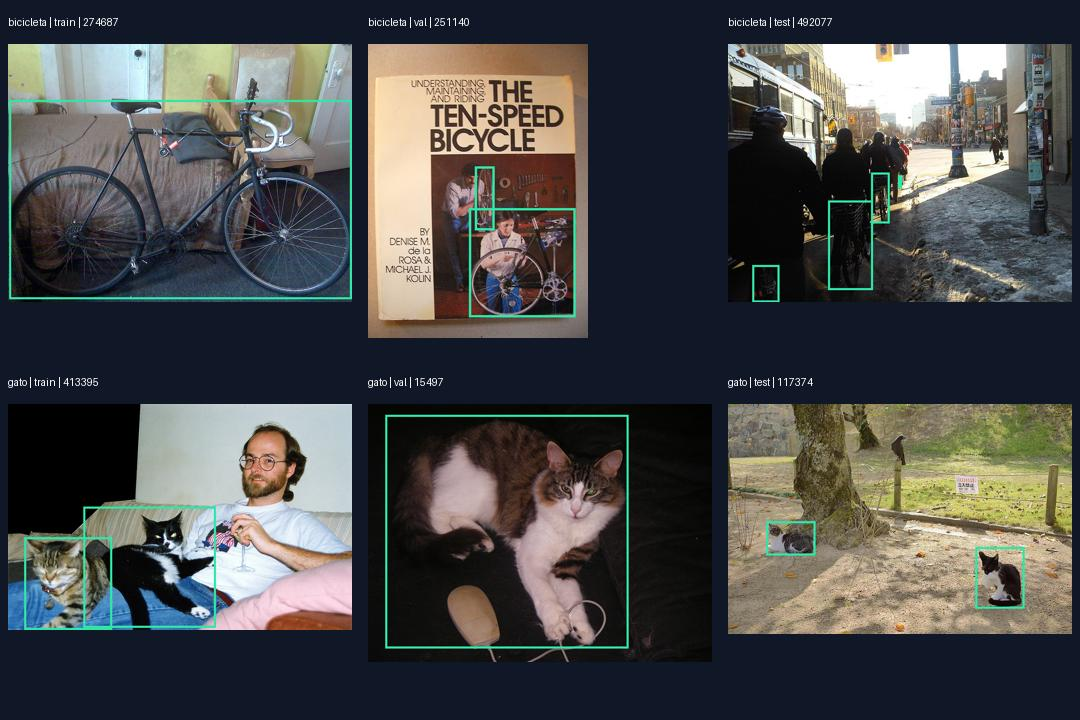

In [4]:
from IPython.display import display, Markdown, Image as DisplayImage
display(prepare_dataset(DATA, CACHE))
manifest = pd.read_csv(DATA/'manifest.csv')
display(manifest[['filename','classe','split','license_id']].head())
display(DisplayImage(filename=str(show_samples(DATA, RESULTS/'dataset_samples.jpg'))))

## 5. Rotulação no Make Sense AI

Site utilizado: https://www.makesense.ai/ . O formato é YOLO: uma linha por
objeto com `classe centro_x centro_y largura altura`, normalizados em [0,1].
Ordem obrigatória: **bicicleta = 0, gato = 1**.

As caixas da fonte COCO são **pré-anotações** para importação e conferência no
Make Sense. A exportação do site é guardada separadamente, com hash e arquivo de
status; nunca chamamos as pré-anotações de rotulação manual. Fotos de validação
e teste também precisam de caixas reais para medir mAP.

Para repetir a rotulação, extraia `makesense_import.zip`, carregue as 80 fotos,
crie os dois rótulos nessa ordem, importe os TXT YOLO e confira as caixas. Exporte
novamente em YOLO e salve o ZIP como `dataset/makesense_export.zip`.
Se as caixas forem alteradas, execute novamente os treinos com novos diretórios,
sem reutilizar resultados antigos. Evidências do site ficam em `docs/` quando
a etapa é concluída.

In [5]:
import base64
# Exportação real do Make Sense incorporada para reexecução do mesmo dataset.
if not (DATA/'makesense_export.zip').exists():
    (DATA/'makesense_export.zip').write_bytes(base64.b64decode('UEsDBAoAAAAAANK0Pl0G08vfSwAAAEsAAAAQAAAAMDAwMDAwMDExMTQ5LnR4dDAgMC42MjEyNzAgMC40ODQ3MDcgMC40NDkyNjAgMC40ODMxNzMKMCAwLjI4NzU1MCAwLjM4NTkwNyAwLjIyMTk4MCAwLjQ1NzQxM1BLAwQKAAAAAADStD5dLbyBICUAAAAlAAAAEAAAADAwMDAwMDAxNDAwNy50eHQxIDAuNTkxNTA4IDAuNTMwMjgyIDAuMTE5NzM0IDAuMzQwNDY5UEsDBAoAAAAAANK0Pl1IfdBuJQAAACUAAAAQAAAAMDAwMDAwMDE0ODMxLnR4dDEgMC41MDE1MDAgMC42ODA4OTggMC45OTcwMDAgMC42MzM3MDNQSwMECgAAAAAA0rQ+XWSSXgolAAAAJQAAABAAAAAwMDAwMDAwMTU0OTcudHh0MSAwLjQwMzY0OCAwLjQ5NDM3NSAwLjcwNjE3MiAwLjkwMzM3NVBLAwQKAAAAAADStD5dP8ECsyUAAAAlAAAAEAAAADAwMDAwMDAxODgzMy50eHQxIDAuNTQyMjE5IDAuNDg5ODk0IDAuNTAxMDk0IDAuNzU5NTU0UEsDBAoAAAAAANK0Pl1NtPTtSwAAAEsAAAAQAAAAMDAwMDAwMDM4ODI5LnR4dDAgMC4yOTkxNTYgMC43MjYzNDcgMC4yODg0MDYgMC40NzUyNjkKMCAwLjU2MjQ0NSAwLjc4NDU5MCAwLjIwOTQ4NCAwLjM0NDA3NVBLAwQKAAAAAADStD5dgqbgtpcAAACXAAAAEAAAADAwMDAwMDA1MDE0NS50eHQwIDAuNTQ1ODY1IDAuODM3NzgxIDAuNDU2MjcxIDAuMjk5MTg3CjAgMC43NjgwNDIgMC42NTQ0ODQgMC4wODMwNDIgMC4xOTAyODEKMCAwLjU0MjQ0OCAwLjY2NzQyMiAwLjA3MTgxMyAwLjEwNjk2OQowIDAuODM0ODAyIDAuNjE5MzI4IDAuMDQzMDIxIDAuMDc4NzE5UEsDBAoAAAAAANK0Pl2v+jw2JQAAACUAAAAQAAAAMDAwMDAwMDYxMzMzLnR4dDEgMC4zMTA3NjAgMC41Nzk5NDUgMC41NzUxMjAgMC41OTc0NTJQSwMECgAAAAAA0rQ+XZ10QKslAAAAJQAAABAAAAAwMDAwMDAwNzI4NTIudHh0MCAwLjQ5OTQ2OSAwLjgxNDQ3NyAwLjM2ODI3OCAwLjI0MTE3MlBLAwQKAAAAAADStD5dUUyIK0sAAABLAAAAEAAAADAwMDAwMDA3NDA1OC50eHQwIDAuNjkzMTgwIDAuNzA1OTM3IDAuMDU3Nzk3IDAuMjM3OTYzCjAgMC43ODA5MTQgMC42NjUxMjkgMC4xNzIzMjggMC4zNDgzMzdQSwMECgAAAAAA0rQ+XYSVis8lAAAAJQAAABAAAAAwMDAwMDAwNzY1NDcudHh0MCAwLjE1MzcwMyAwLjc0MzEyNSAwLjMwNzQwNiAwLjUwODU4M1BLAwQKAAAAAADStD5d4PJTpiUAAAAlAAAAEAAAADAwMDAwMDA3ODQyNi50eHQxIDAuMjc1NjkwIDAuNTc0MzQxIDAuNTUxMzgwIDAuNzYyOTM0UEsDBAoAAAAAANK0Pl0BurNIJQAAACUAAAAQAAAAMDAwMDAwMDg0MzYyLnR4dDEgMC42MzcyMDMgMC43MjcxMTUgMC40NjAyMTkgMC40MTEyNzFQSwMECgAAAAAA0rQ+XVkwcmglAAAAJQAAABAAAAAwMDAwMDAwODkyNzEudHh0MSAwLjQ4NDkyMiAwLjY1NTc5MiAwLjk2OTg0NCAwLjY2NTI0OFBLAwQKAAAAAADStD5d4umyJiUAAAAlAAAAEAAAADAwMDAwMDEwMTQyMC50eHQxIDAuMzIzMzcwIDAuMzEzNjI3IDAuNDAxMzAwIDAuMzAzODkzUEsDBAoAAAAAANK0Pl1Cml2WJQAAACUAAAAQAAAAMDAwMDAwMTA2Mzg5LnR4dDEgMC4yNTM3NjYgMC4zNzUwMDAgMC4yMjMwNjIgMC40MDA4NzVQSwMECgAAAAAA0rQ+Xe6eRiElAAAAJQAAABAAAAAwMDAwMDAxMTY4MjUudHh0MSAwLjM2NTk0NSAwLjUwMjI1MCAwLjQ5OTI5NyAwLjk3MzA1NlBLAwQKAAAAAADStD5dMRm5XUsAAABLAAAAEAAAADAwMDAwMDExNzM3NC50eHQxIDAuNzkwNDc3IDAuNzU2MTgwIDAuMTQxMjY2IDAuMjY3NDA3CjEgMC4xODIyNjYgMC41ODQ1MjEgMC4xNDI2MjUgMC4xNDc3MzRQSwMECgAAAAAA0rQ+XUImsIglAAAAJQAAABAAAAAwMDAwMDAxMTkyMzMudHh0MSAwLjQ2OTk5MCAwLjUzNzE0MSAwLjg4OTE4MCAwLjQ4NzY5NVBLAwQKAAAAAADStD5d2Ybq7CUAAAAlAAAAEAAAADAwMDAwMDEzMTEzMS50eHQxIDAuNDIxNzczIDAuNjY5ODk2IDAuNTk1MTcyIDAuNjM4NzA4UEsDBAoAAAAAANK0Pl3Pm1G4JQAAACUAAAAQAAAAMDAwMDAwMTM0MDk2LnR4dDEgMC42Njc3NDIgMC42MDM2NDYgMC42NjQ1MTYgMC43NjU1ODNQSwMECgAAAAAA0rQ+XV009j0lAAAAJQAAABAAAAAwMDAwMDAxMzU2NzAudHh0MCAwLjY2NDgwMCAwLjU3Mjk2MCAwLjI4MDE2MCAwLjM0NzE2MFBLAwQKAAAAAADStD5dycNpYiUAAAAlAAAAEAAAADAwMDAwMDEzOTY4NC50eHQxIDAuNTIxMzQwIDAuNzk3ODUzIDAuMjgwNzIwIDAuMTc2MzY2UEsDBAoAAAAAANK0Pl0R5EijJQAAACUAAAAQAAAAMDAwMDAwMTQ0MzMzLnR4dDAgMC41MDE5MDEgMC43MDE3OTcgMC42NTM0NzQgMC41NTE1NjJQSwMECgAAAAAA0rQ+XdPs1uIlAAAAJQAAABAAAAAwMDAwMDAxNTUyOTEudHh0MSAwLjQ5MjE0MSAwLjUwNTc5NiAwLjg3NTI1MCAwLjYzMDA5NFBLAwQKAAAAAADStD5dGgfIvyUAAAAlAAAAEAAAADAwMDAwMDE3MjMzMC50eHQxIDAuNTIwMzIwIDAuNTc2NTMxIDAuMjc4MDE2IDAuMjM5NTIxUEsDBAoAAAAAANK0Pl3w29tiJQAAACUAAAAQAAAAMDAwMDAwMTc0NDgyLnR4dDAgMC41MzU4NDQgMC41MDUzNzQgMC40ODUwMDAgMC45ODA2NDRQSwMECgAAAAAA0rQ+XVVco6wlAAAAJQAAABAAAAAwMDAwMDAxODE4NTkudHh0MSAwLjQ5OTE2NyAwLjU1NTkxNCAwLjU0NjAzMyAwLjQxOTM1OVBLAwQKAAAAAADStD5d+O+eSeMAAADjAAAAEAAAADAwMDAwMDE4NTE1Ny50eHQwIDAuNzE1NjM0IDAuOTMyMjU4IDAuMzI2MzM4IDAuMTMxMTcyCjAgMC4zNjI4MTcgMC45MTQ5NjkgMC42NzExMjcgMC4xNzAwNjIKMCAwLjQzNDgxMiAwLjk0OTQ5MiAwLjE3MzQ3NCAwLjEwMTAxNgowIDAuMzM5MjI1IDAuODU3NDc3IDAuMTM5ODEyIDAuMDgyOTIyCjAgMC4wNjkwODUgMC44ODg0ODQgMC4xMzgxNjkgMC4xNzk1NjMKMCAwLjE3OTI2MSAwLjg4MzI0MiAwLjA4NzcyMyAwLjAzMDAxNlBLAwQKAAAAAADStD5dBtziuCUAAAAlAAAAEAAAADAwMDAwMDE5MzkyNi50eHQwIDAuNzY2OTQ1IDAuMTA3NTI2IDAuMzgzMDc4IDAuMTM3NjUyUEsDBAoAAAAAANK0Pl0nJL6/cQAAAHEAAAAQAAAAMDAwMDAwMTk2ODQzLnR4dDAgMC43ODE1NTUgMC42OTk1NTIgMC4xODAyNjYgMC4zMDA5MzgKMCAwLjEwNDM3NSAwLjg5MzEyNSAwLjIwODc1MCAwLjIxMzc1MAowIDAuMDEyNzU4IDAuNzg2NDc5IDAuMDI1NTE2IDAuMDQ3MTI1UEsDBAoAAAAAANK0Pl33OU6IJQAAACUAAAAQAAAAMDAwMDAwMjAzMzE3LnR4dDAgMC42ODMxNjAgMC43Mzk3ODcgMC41MTQ4ODAgMC40ODE3MDJQSwMECgAAAAAA0rQ+XSUFgP4lAAAAJQAAABAAAAAwMDAwMDAyMTAyOTkudHh0MCAwLjMxMDQxNCAwLjYwOTA5NCAwLjE5NDQ1MyAwLjQ1MTg1NFBLAwQKAAAAAADStD5dQ0gDMyUAAAAlAAAAEAAAADAwMDAwMDIyNDA1MS50eHQwIDAuNjY2NjI1IDAuNTExMTIyIDAuMjQzMzc1IDAuNjcyNjE3UEsDBAoAAAAAANK0Pl1x+IZHSwAAAEsAAAAQAAAAMDAwMDAwMjI4NDM2LnR4dDAgMC41MjIzOTggMC42NzI0NTQgMC42OTM4NTkgMC42NDExOTYKMCAwLjA4NTA2MyAwLjM4OTU5OCAwLjAxMDE4OCAwLjAyOTUwNVBLAwQKAAAAAADStD5d/rFU5yUAAAAlAAAAEAAAADAwMDAwMDI0MDk0MC50eHQxIDAuNDUxMDkyIDAuODAwMDAwIDAuMjQwMTEyIDAuMzc0MDQwUEsDBAoAAAAAANK0Pl2Kw8evJQAAACUAAAAQAAAAMDAwMDAwMjQyMjg3LnR4dDAgMC40MTQyNzIgMC43ODk3MDMgMC43MzgyNjMgMC4zODE5NjlQSwMECgAAAAAA0rQ+XWrE6eYlAAAAJQAAABAAAAAwMDAwMDAyNDMzNDQudHh0MSAwLjQ3NzI0MCAwLjQwMTk2MSAwLjIxMTE0NiAwLjI5OTEwOVBLAwQKAAAAAADStD5dAMSIK0sAAABLAAAAEAAAADAwMDAwMDI1MTE0MC50eHQwIDAuNzAxMTIwIDAuNzQ0NTMwIDAuNDgzNTIwIDAuMzcwNzQwCjAgMC41Mjk4MTMgMC41MjQ3MDAgMC4wODg3NDcgMC4yMTU5NjBQSwMECgAAAAAA0rQ+XU8ssDVxAAAAcQAAABAAAAAwMDAwMDAyNTk4MzAudHh0MCAwLjc0MDQzNSAwLjc5MTQyMiAwLjIyMDk2NSAwLjE5MzcxOQowIDAuODk4MzI5IDAuNzg2MDIzIDAuMjAzMzQxIDAuMjM4NzAzCjAgMC41OTg0MDAgMC44MTAyMzQgMC4xNjAxNDEgMC4xMjk5NjlQSwMECgAAAAAA0rQ+Xd+qeAwlAAAAJQAAABAAAAAwMDAwMDAyNjE4ODgudHh0MCAwLjY3Nzc2NiAwLjc2MzEzNCAwLjI5NTY4NyAwLjM0MTE5N1BLAwQKAAAAAADStD5dkey31yUAAAAlAAAAEAAAADAwMDAwMDI3NDY4Ny50eHQwIDAuNTAxNjA5IDAuNjAzMjI5IDAuOTk2NzgxIDAuNzcyMDQyUEsDBAoAAAAAANK0Pl0PYUQrJQAAACUAAAAQAAAAMDAwMDAwMjc5MTQ1LnR4dDEgMC4yNDI0MjIgMC44MjQyNjAgMC4xNjA0NjkgMC4zMDI4MTJQSwMECgAAAAAA0rQ+XTlflmMlAAAAJQAAABAAAAAwMDAwMDAyODE5MjkudHh0MCAwLjQ5NDUxNiAwLjY3NTY5NCAwLjYyNjYyNSAwLjU0NDA4N1BLAwQKAAAAAADStD5dCyFg5yUAAAAlAAAAEAAAADAwMDAwMDI4NzY0OS50eHQxIDAuNjA2NzUwIDAuNDIzMTc3IDAuNzg2NTAwIDAuODI4NDM4UEsDBAoAAAAAANK0Pl2Tj17AJQAAACUAAAAQAAAAMDAwMDAwMjkxNjM0LnR4dDAgMC41MTc2NDQgMC42ODk2NDggMC44NTA1MzEgMC40MDczMjhQSwMECgAAAAAA0rQ+XUdrOVclAAAAJQAAABAAAAAwMDAwMDAyOTU4MDkudHh0MCAwLjQ2MTE2NCAwLjc2NjUxNCAwLjUyOTMyOCAwLjM5NTA1OVBLAwQKAAAAAADStD5dyftquiUAAAAlAAAAEAAAADAwMDAwMDMxNjAxNS50eHQxIDAuNzY3ODUwIDAuNjY2MDUwIDAuMzExNjYwIDAuNTA4ODAwUEsDBAoAAAAAANK0Pl3oCcKnJQAAACUAAAAQAAAAMDAwMDAwMzI3NzY5LnR4dDEgMC41MTA4MjggMC40NDMzMDIgMC4zOTIwNjIgMC4zMzkxMDRQSwMECgAAAAAA0rQ+Xe6I3G8lAAAAJQAAABAAAAAwMDAwMDAzMjkzMTkudHh0MSAwLjU1NzA0NCAwLjU4NTM5MSAwLjcwOTY5NiAwLjQxMDg3NVBLAwQKAAAAAADStD5dBTXf70sAAABLAAAAEAAAADAwMDAwMDMzMzc3Mi50eHQxIDAuNTY3MTQwIDAuNjcyNjAwIDAuNDQ4OTIwIDAuNTMxNzA3CjEgMC41MTE1MjAgMC41NTE2ODAgMC43NTMzNjAgMC40NDcyMDBQSwMECgAAAAAA0rQ+XXVE2ZclAAAAJQAAABAAAAAwMDAwMDAzNTE1MzAudHh0MCAwLjEwMzUwOCAwLjUyMzEyMiAwLjIwNjQ4NCAwLjI2OTEwMVBLAwQKAAAAAADStD5dvB/OhyUAAAAlAAAAEAAAADAwMDAwMDM1NjYxMi50eHQwIDAuODc0ODk4IDAuNjUxOTk1IDAuMTcxMDQ3IDAuMjg1NTc3UEsDBAoAAAAAANK0Pl0+OtPlJQAAACUAAAAQAAAAMDAwMDAwMzU3OTQxLnR4dDEgMC41NjIxMDAgMC40NjM4MDAgMC40Nzg2MDAgMC4yMDM0NDBQSwMECgAAAAAA0rQ+XasMJu4lAAAAJQAAABAAAAAwMDAwMDAzNjYxOTkudHh0MSAwLjUwOTAxNiAwLjQ5NjYyOCAwLjI3NzM3NSAwLjE4ODc1OVBLAwQKAAAAAADStD5dCSDBWCUAAAAlAAAAEAAAADAwMDAwMDM3MDIwOC50eHQwIDAuNTA2NDUwIDAuNTkwMzIwIDAuNzYxMzAwIDAuNjA4NTg3UEsDBAoAAAAAANK0Pl0625j4JQAAACUAAAAQAAAAMDAwMDAwMzg0NTI3LnR4dDAgMC43NTUwNDcgMC4zMTE5MTcgMC4yODU4NzUgMC4xODgzMzNQSwMECgAAAAAA0rQ+XWQL8CBLAAAASwAAABAAAAAwMDAwMDAzOTQ1MTAudHh0MCAwLjc4Mjg0NCAwLjIyNjA0MiAwLjI5NjMxMiAwLjM5MzkxNwowIDAuOTI5NTc4IDAuMTczMzU0IDAuMTQwODQ0IDAuMjc4NjY3UEsDBAoAAAAAANK0Pl2h1euFJQAAACUAAAAQAAAAMDAwMDAwNDAzNTY1LnR4dDAgMC40NDM5NDkgMC42NjQ3NjYgMC43MTI5NTMgMC4zMzM1NjJQSwMECgAAAAAA0rQ+XU33qvclAAAAJQAAABAAAAAwMDAwMDA0MDc5NjAudHh0MSAwLjMxOTkwNiAwLjYyODIyOCAwLjQ2NzY1NiAwLjUxMjkzNFBLAwQKAAAAAADStD5drUbqZ0sAAABLAAAAEAAAADAwMDAwMDQxMzM5NS50eHQxIDAuMTc1NDE0IDAuNzkzNTM5IDAuMjU0NjQxIDAuNDA4NTk5CjEgMC40MTIwMDggMC43MjE4MjkgMC4zODQ1NDcgMC41MzUzNDRQSwMECgAAAAAA0rQ+XXFkBSolAAAAJQAAABAAAAAwMDAwMDA0MTQ1MTAudHh0MCAwLjU5NTU3MyAwLjY4Mzc1OCAwLjU3NzgxMiAwLjE0MjYwOVBLAwQKAAAAAADStD5d1QE+ISUAAAAlAAAAEAAAADAwMDAwMDQxNjI1Ni50eHQxIDAuNDg2MjkwIDAuNDM0NDEzIDAuNTAxNjIwIDAuNDA4NjEzUEsDBAoAAAAAANK0Pl1EbjOrlwAAAJcAAAAQAAAAMDAwMDAwNDI0MTYyLnR4dDAgMC41Njg5MzcgMC42ODgyMDMgMC4xODMwMDAgMC40NzY0NDUKMCAwLjg0MjIyNyAwLjcwNDE4MCAwLjE3ODkyMiAwLjQ2NzczNAowIDAuNjQyNTc4IDAuNjg5MjQ4IDAuMTIyMTU2IDAuMzcyMDUxCjAgMC44MzMzMzYgMC4zMjc3MzQgMC4wNDk0NTMgMC4wNDcyMjdQSwMECgAAAAAA0rQ+Xafw4KMlAAAAJQAAABAAAAAwMDAwMDA0MjQ1NDUudHh0MSAwLjY0Njc3MCAwLjQ3MDk3MyAwLjcwNjQ2MCAwLjcwOTY4MFBLAwQKAAAAAADStD5dXJLlkSUAAAAlAAAAEAAAADAwMDAwMDQyNjE2Ni50eHQwIDAuMzYxMjcwIDAuNzA2NDQ2IDAuMjk5ODYwIDAuMzcyMDQ4UEsDBAoAAAAAANK0Pl24KLQ6JQAAACUAAAAQAAAAMDAwMDAwNDMyNDY4LnR4dDEgMC40MzExMjQgMC4yMDU2MTcgMC44NjIyNDggMC4zMTIzNTlQSwMECgAAAAAA0rQ+XS3vYzwlAAAAJQAAABAAAAAwMDAwMDA0NjkwNjcudHh0MSAwLjY2MjcxOSAwLjc0Njc3MSAwLjQxMDU2MiAwLjQ3NDEyNVBLAwQKAAAAAADStD5dRrgmMCUAAAAlAAAAEAAAADAwMDAwMDQ3MjYyMy50eHQwIDAuNzI1MzQxIDAuNzQyNDg0IDAuNTQ5MzE4IDAuMzk4ODEzUEsDBAoAAAAAANK0Pl2sXz0eJQAAACUAAAAQAAAAMDAwMDAwNDc2ODEwLnR4dDEgMC4zOTAyNTggMC4zNDcxMDQgMC43ODA1MTYgMC42MzM4MzNQSwMECgAAAAAA0rQ+XV0IDtNLAAAASwAAABAAAAAwMDAwMDA0NzgzOTMudHh0MSAwLjM2MTAwMCAwLjMwODU5NCAwLjMwMzA0MiAwLjEwNjAzMQoxIDAuMjY4MTA0IDAuNjgyNzk3IDAuNTMwNDU4IDAuMjM0NDA2UEsDBAoAAAAAANK0Pl0VW2lulwAAAJcAAAAQAAAAMDAwMDAwNDkyMDc3LnR4dDAgMC4zNTU5MzAgMC43ODExMzUgMC4xMjkxNDEgMC4zNDU2NDYKMCAwLjQ0MzQ1MyAwLjU5NzA2MyAwLjA1MzM3NSAwLjE5NzE2NwowIDAuNTAwMjQyIDAuNTMzOTE3IDAuMDEwMTcyIDAuMDQ5MDAwCjAgMC4xMTAyMjcgMC45Mjg0OTAgMC4wNzcxNDEgMC4xNDMwMjBQSwMECgAAAAAA0rQ+XXHloRclAAAAJQAAABAAAAAwMDAwMDA0OTI5MzcudHh0MCAwLjQyMDk4MCAwLjUwNDE5MSAwLjc3NDYwOCAwLjk1NTk2NFBLAwQKAAAAAADStD5dxnUEdQkBAAAJAQAAEAAAADAwMDAwMDUwNzAzNy50eHQwIDAuNzAyNjY0IDAuNzc5MTg4IDAuMjc4NzY2IDAuMjUzODMzCjAgMC40MDM3ODkgMC45NzU1OTQgMC4yNDk3NjYgMC4wNDg4MTIKMCAwLjI0MDA3MCAwLjY4NDI0MCAwLjA2NTg1OSAwLjA1NjQzOAowIDAuMDgyMDYyIDAuOTM2NDY5IDAuMTY0MTI0IDAuMTAzNTIxCjAgMC44MTM2MzMgMC43NzYzODUgMC4yNDY1NzggMC4xODIzMTIKMCAwLjY4MTE3MiAwLjc2NTE4OCAwLjAyMzk2OSAwLjA1NDA4MwowIDAuNDUwOTY5IDAuNzQ4NzE5IDAuMDM2MDk0IDAuMDc0NzcxUEsDBAoAAAAAANK0Pl2WO0F7JQAAACUAAAAQAAAAMDAwMDAwNTI1MjQ3LnR4dDEgMC4zMDI2ODAgMC41OTkxNDUgMC41OTY3MzQgMC43NDc4NDVQSwMECgAAAAAA0rQ+XSfBuo4lAAAAJQAAABAAAAAwMDAwMDA1NDM1ODEudHh0MSAwLjg3MTM3NSAwLjg0NDgyNCAwLjIyNDMxMiAwLjE5ODI2N1BLAwQKAAAAAADStD5d4c+sMuMAAADjAAAAEAAAADAwMDAwMDU0OTM5MC50eHQwIDAuOTMxOTE0IDAuNTIzNTgzIDAuMDIzMDQ3IDAuMDUwNDkyCjAgMC4zNTA3ODEgMC43MzMwMjEgMC41MDAwMDAgMC41MzM5NTgKMCAwLjcxMDc5NyAwLjU2NjA3NyAwLjA3OTYyNSAwLjA4OTY3MgowIDAuODcyNDIyIDAuNTE4ODk5IDAuMDI3OTA2IDAuMDczMDIxCjAgMC45NTA4OTggMC41MzIxMzEgMC4wMzAwNDcgMC4wODAyMzQKMCAwLjk4OTA5NCAwLjUyNDc0MiAwLjAyMTgxMiAwLjA1NzMwN1BLAwQKAAAAAADStD5dq4llRUsAAABLAAAAEAAAADAwMDAwMDU3MDY2NC50eHQxIDAuNzM2OTAwIDAuNjg0OTU1IDAuMzcwOTYwIDAuNTg3MDg3CjEgMC41MzQzNDAgMC4yNzE5NTIgMC4zNjE2ODAgMC40NzYwMzZQSwMECgAAAAAA0rQ+XeKbZeahAQAAoQEAABAAAAAwMDAwMDA1NzA4MzQudHh0MCAwLjQ5MzU0NyAwLjcxNTc3MSAwLjEyNTgxMiAwLjMwOTY2NwowIDAuNTY1OTIyIDAuNzI0ODAyIDAuMTIwNzUwIDAuMzQyNjA0CjAgMC42MTc2MjUgMC43MDU2MDQgMC4xMjM0MzggMC4zMzc2NjcKMCAwLjI4MzU0NyAwLjUxNDM5NiAwLjA0NjU2MiAwLjE1NjU4MwowIDAuNDI4MTQxIDAuNTQyODQ0IDAuMDQ2NDY5IDAuMTI1NTIxCjAgMC40MTIwMzkgMC41MzM2MTUgMC4wNTY3MzQgMC4xMzkxMDQKMCAwLjQ2NDM5MSAwLjU0MjcxOSAwLjA0NjkzOCAwLjE0NTEwNAowIDAuMjU3MjczIDAuNDUyODMzIDAuMDQ2MjM0IDAuMDkwMTI1CjAgMC42NzI3MjcgMC42OTE5MzcgMC4xMTY3NjYgMC4zMjg1NDIKMCAwLjQ4MjQwNiAwLjUwOTE5OCAwLjAzNzc1MCAwLjEwMDE0NgowIDAuMzA2NTM5IDAuNTQzMDUyIDAuMDEyNjcyIDAuMTA0MjcxUEsDBAoAAAAAANK0Pl2aWyz9JQAAACUAAAAQAAAAMDAwMDAwNTczMDk0LnR4dDAgMC44NDE5NDcgMC44MDAzMTAgMC4zMTI2NDAgMC4zOTc1ODBQSwECFAAKAAAAAADStD5dBtPL30sAAABLAAAAEAAAAAAAAAAAAAAAAAAAAAAAMDAwMDAwMDExMTQ5LnR4dFBLAQIUAAoAAAAAANK0Pl0tvIEgJQAAACUAAAAQAAAAAAAAAAAAAAAAAHkAAAAwMDAwMDAwMTQwMDcudHh0UEsBAhQACgAAAAAA0rQ+XUh90G4lAAAAJQAAABAAAAAAAAAAAAAAAAAAzAAAADAwMDAwMDAxNDgzMS50eHRQSwECFAAKAAAAAADStD5dZJJeCiUAAAAlAAAAEAAAAAAAAAAAAAAAAAAfAQAAMDAwMDAwMDE1NDk3LnR4dFBLAQIUAAoAAAAAANK0Pl0/wQKzJQAAACUAAAAQAAAAAAAAAAAAAAAAAHIBAAAwMDAwMDAwMTg4MzMudHh0UEsBAhQACgAAAAAA0rQ+XU209O1LAAAASwAAABAAAAAAAAAAAAAAAAAAxQEAADAwMDAwMDAzODgyOS50eHRQSwECFAAKAAAAAADStD5dgqbgtpcAAACXAAAAEAAAAAAAAAAAAAAAAAA+AgAAMDAwMDAwMDUwMTQ1LnR4dFBLAQIUAAoAAAAAANK0Pl2v+jw2JQAAACUAAAAQAAAAAAAAAAAAAAAAAAMDAAAwMDAwMDAwNjEzMzMudHh0UEsBAhQACgAAAAAA0rQ+XZ10QKslAAAAJQAAABAAAAAAAAAAAAAAAAAAVgMAADAwMDAwMDA3Mjg1Mi50eHRQSwECFAAKAAAAAADStD5dUUyIK0sAAABLAAAAEAAAAAAAAAAAAAAAAACpAwAAMDAwMDAwMDc0MDU4LnR4dFBLAQIUAAoAAAAAANK0Pl2ElYrPJQAAACUAAAAQAAAAAAAAAAAAAAAAACIEAAAwMDAwMDAwNzY1NDcudHh0UEsBAhQACgAAAAAA0rQ+XeDyU6YlAAAAJQAAABAAAAAAAAAAAAAAAAAAdQQAADAwMDAwMDA3ODQyNi50eHRQSwECFAAKAAAAAADStD5dAbqzSCUAAAAlAAAAEAAAAAAAAAAAAAAAAADIBAAAMDAwMDAwMDg0MzYyLnR4dFBLAQIUAAoAAAAAANK0Pl1ZMHJoJQAAACUAAAAQAAAAAAAAAAAAAAAAABsFAAAwMDAwMDAwODkyNzEudHh0UEsBAhQACgAAAAAA0rQ+XeLpsiYlAAAAJQAAABAAAAAAAAAAAAAAAAAAbgUAADAwMDAwMDEwMTQyMC50eHRQSwECFAAKAAAAAADStD5dQppdliUAAAAlAAAAEAAAAAAAAAAAAAAAAADBBQAAMDAwMDAwMTA2Mzg5LnR4dFBLAQIUAAoAAAAAANK0Pl3unkYhJQAAACUAAAAQAAAAAAAAAAAAAAAAABQGAAAwMDAwMDAxMTY4MjUudHh0UEsBAhQACgAAAAAA0rQ+XTEZuV1LAAAASwAAABAAAAAAAAAAAAAAAAAAZwYAADAwMDAwMDExNzM3NC50eHRQSwECFAAKAAAAAADStD5dQiawiCUAAAAlAAAAEAAAAAAAAAAAAAAAAADgBgAAMDAwMDAwMTE5MjMzLnR4dFBLAQIUAAoAAAAAANK0Pl3ZhursJQAAACUAAAAQAAAAAAAAAAAAAAAAADMHAAAwMDAwMDAxMzExMzEudHh0UEsBAhQACgAAAAAA0rQ+Xc+bUbglAAAAJQAAABAAAAAAAAAAAAAAAAAAhgcAADAwMDAwMDEzNDA5Ni50eHRQSwECFAAKAAAAAADStD5dXTT2PSUAAAAlAAAAEAAAAAAAAAAAAAAAAADZBwAAMDAwMDAwMTM1NjcwLnR4dFBLAQIUAAoAAAAAANK0Pl3Jw2liJQAAACUAAAAQAAAAAAAAAAAAAAAAACwIAAAwMDAwMDAxMzk2ODQudHh0UEsBAhQACgAAAAAA0rQ+XRHkSKMlAAAAJQAAABAAAAAAAAAAAAAAAAAAfwgAADAwMDAwMDE0NDMzMy50eHRQSwECFAAKAAAAAADStD5d0+zW4iUAAAAlAAAAEAAAAAAAAAAAAAAAAADSCAAAMDAwMDAwMTU1MjkxLnR4dFBLAQIUAAoAAAAAANK0Pl0aB8i/JQAAACUAAAAQAAAAAAAAAAAAAAAAACUJAAAwMDAwMDAxNzIzMzAudHh0UEsBAhQACgAAAAAA0rQ+XfDb22IlAAAAJQAAABAAAAAAAAAAAAAAAAAAeAkAADAwMDAwMDE3NDQ4Mi50eHRQSwECFAAKAAAAAADStD5dVVyjrCUAAAAlAAAAEAAAAAAAAAAAAAAAAADLCQAAMDAwMDAwMTgxODU5LnR4dFBLAQIUAAoAAAAAANK0Pl34755J4wAAAOMAAAAQAAAAAAAAAAAAAAAAAB4KAAAwMDAwMDAxODUxNTcudHh0UEsBAhQACgAAAAAA0rQ+XQbc4rglAAAAJQAAABAAAAAAAAAAAAAAAAAALwsAADAwMDAwMDE5MzkyNi50eHRQSwECFAAKAAAAAADStD5dJyS+v3EAAABxAAAAEAAAAAAAAAAAAAAAAACCCwAAMDAwMDAwMTk2ODQzLnR4dFBLAQIUAAoAAAAAANK0Pl33OU6IJQAAACUAAAAQAAAAAAAAAAAAAAAAACEMAAAwMDAwMDAyMDMzMTcudHh0UEsBAhQACgAAAAAA0rQ+XSUFgP4lAAAAJQAAABAAAAAAAAAAAAAAAAAAdAwAADAwMDAwMDIxMDI5OS50eHRQSwECFAAKAAAAAADStD5dQ0gDMyUAAAAlAAAAEAAAAAAAAAAAAAAAAADHDAAAMDAwMDAwMjI0MDUxLnR4dFBLAQIUAAoAAAAAANK0Pl1x+IZHSwAAAEsAAAAQAAAAAAAAAAAAAAAAABoNAAAwMDAwMDAyMjg0MzYudHh0UEsBAhQACgAAAAAA0rQ+Xf6xVOclAAAAJQAAABAAAAAAAAAAAAAAAAAAkw0AADAwMDAwMDI0MDk0MC50eHRQSwECFAAKAAAAAADStD5disPHryUAAAAlAAAAEAAAAAAAAAAAAAAAAADmDQAAMDAwMDAwMjQyMjg3LnR4dFBLAQIUAAoAAAAAANK0Pl1qxOnmJQAAACUAAAAQAAAAAAAAAAAAAAAAADkOAAAwMDAwMDAyNDMzNDQudHh0UEsBAhQACgAAAAAA0rQ+XQDEiCtLAAAASwAAABAAAAAAAAAAAAAAAAAAjA4AADAwMDAwMDI1MTE0MC50eHRQSwECFAAKAAAAAADStD5dTyywNXEAAABxAAAAEAAAAAAAAAAAAAAAAAAFDwAAMDAwMDAwMjU5ODMwLnR4dFBLAQIUAAoAAAAAANK0Pl3fqngMJQAAACUAAAAQAAAAAAAAAAAAAAAAAKQPAAAwMDAwMDAyNjE4ODgudHh0UEsBAhQACgAAAAAA0rQ+XZHst9clAAAAJQAAABAAAAAAAAAAAAAAAAAA9w8AADAwMDAwMDI3NDY4Ny50eHRQSwECFAAKAAAAAADStD5dD2FEKyUAAAAlAAAAEAAAAAAAAAAAAAAAAABKEAAAMDAwMDAwMjc5MTQ1LnR4dFBLAQIUAAoAAAAAANK0Pl05X5ZjJQAAACUAAAAQAAAAAAAAAAAAAAAAAJ0QAAAwMDAwMDAyODE5MjkudHh0UEsBAhQACgAAAAAA0rQ+XQshYOclAAAAJQAAABAAAAAAAAAAAAAAAAAA8BAAADAwMDAwMDI4NzY0OS50eHRQSwECFAAKAAAAAADStD5dk49ewCUAAAAlAAAAEAAAAAAAAAAAAAAAAABDEQAAMDAwMDAwMjkxNjM0LnR4dFBLAQIUAAoAAAAAANK0Pl1HazlXJQAAACUAAAAQAAAAAAAAAAAAAAAAAJYRAAAwMDAwMDAyOTU4MDkudHh0UEsBAhQACgAAAAAA0rQ+Xcn7arolAAAAJQAAABAAAAAAAAAAAAAAAAAA6REAADAwMDAwMDMxNjAxNS50eHRQSwECFAAKAAAAAADStD5d6AnCpyUAAAAlAAAAEAAAAAAAAAAAAAAAAAA8EgAAMDAwMDAwMzI3NzY5LnR4dFBLAQIUAAoAAAAAANK0Pl3uiNxvJQAAACUAAAAQAAAAAAAAAAAAAAAAAI8SAAAwMDAwMDAzMjkzMTkudHh0UEsBAhQACgAAAAAA0rQ+XQU13+9LAAAASwAAABAAAAAAAAAAAAAAAAAA4hIAADAwMDAwMDMzMzc3Mi50eHRQSwECFAAKAAAAAADStD5ddUTZlyUAAAAlAAAAEAAAAAAAAAAAAAAAAABbEwAAMDAwMDAwMzUxNTMwLnR4dFBLAQIUAAoAAAAAANK0Pl28H86HJQAAACUAAAAQAAAAAAAAAAAAAAAAAK4TAAAwMDAwMDAzNTY2MTIudHh0UEsBAhQACgAAAAAA0rQ+XT460+UlAAAAJQAAABAAAAAAAAAAAAAAAAAAARQAADAwMDAwMDM1Nzk0MS50eHRQSwECFAAKAAAAAADStD5dqwwm7iUAAAAlAAAAEAAAAAAAAAAAAAAAAABUFAAAMDAwMDAwMzY2MTk5LnR4dFBLAQIUAAoAAAAAANK0Pl0JIMFYJQAAACUAAAAQAAAAAAAAAAAAAAAAAKcUAAAwMDAwMDAzNzAyMDgudHh0UEsBAhQACgAAAAAA0rQ+XTrbmPglAAAAJQAAABAAAAAAAAAAAAAAAAAA+hQAADAwMDAwMDM4NDUyNy50eHRQSwECFAAKAAAAAADStD5dZAvwIEsAAABLAAAAEAAAAAAAAAAAAAAAAABNFQAAMDAwMDAwMzk0NTEwLnR4dFBLAQIUAAoAAAAAANK0Pl2h1euFJQAAACUAAAAQAAAAAAAAAAAAAAAAAMYVAAAwMDAwMDA0MDM1NjUudHh0UEsBAhQACgAAAAAA0rQ+XU33qvclAAAAJQAAABAAAAAAAAAAAAAAAAAAGRYAADAwMDAwMDQwNzk2MC50eHRQSwECFAAKAAAAAADStD5drUbqZ0sAAABLAAAAEAAAAAAAAAAAAAAAAABsFgAAMDAwMDAwNDEzMzk1LnR4dFBLAQIUAAoAAAAAANK0Pl1xZAUqJQAAACUAAAAQAAAAAAAAAAAAAAAAAOUWAAAwMDAwMDA0MTQ1MTAudHh0UEsBAhQACgAAAAAA0rQ+XdUBPiElAAAAJQAAABAAAAAAAAAAAAAAAAAAOBcAADAwMDAwMDQxNjI1Ni50eHRQSwECFAAKAAAAAADStD5dRG4zq5cAAACXAAAAEAAAAAAAAAAAAAAAAACLFwAAMDAwMDAwNDI0MTYyLnR4dFBLAQIUAAoAAAAAANK0Pl2n8OCjJQAAACUAAAAQAAAAAAAAAAAAAAAAAFAYAAAwMDAwMDA0MjQ1NDUudHh0UEsBAhQACgAAAAAA0rQ+XVyS5ZElAAAAJQAAABAAAAAAAAAAAAAAAAAAoxgAADAwMDAwMDQyNjE2Ni50eHRQSwECFAAKAAAAAADStD5duCi0OiUAAAAlAAAAEAAAAAAAAAAAAAAAAAD2GAAAMDAwMDAwNDMyNDY4LnR4dFBLAQIUAAoAAAAAANK0Pl0t72M8JQAAACUAAAAQAAAAAAAAAAAAAAAAAEkZAAAwMDAwMDA0NjkwNjcudHh0UEsBAhQACgAAAAAA0rQ+XUa4JjAlAAAAJQAAABAAAAAAAAAAAAAAAAAAnBkAADAwMDAwMDQ3MjYyMy50eHRQSwECFAAKAAAAAADStD5drF89HiUAAAAlAAAAEAAAAAAAAAAAAAAAAADvGQAAMDAwMDAwNDc2ODEwLnR4dFBLAQIUAAoAAAAAANK0Pl1dCA7TSwAAAEsAAAAQAAAAAAAAAAAAAAAAAEIaAAAwMDAwMDA0NzgzOTMudHh0UEsBAhQACgAAAAAA0rQ+XRVbaW6XAAAAlwAAABAAAAAAAAAAAAAAAAAAuxoAADAwMDAwMDQ5MjA3Ny50eHRQSwECFAAKAAAAAADStD5dceWhFyUAAAAlAAAAEAAAAAAAAAAAAAAAAACAGwAAMDAwMDAwNDkyOTM3LnR4dFBLAQIUAAoAAAAAANK0Pl3GdQR1CQEAAAkBAAAQAAAAAAAAAAAAAAAAANMbAAAwMDAwMDA1MDcwMzcudHh0UEsBAhQACgAAAAAA0rQ+XZY7QXslAAAAJQAAABAAAAAAAAAAAAAAAAAACh0AADAwMDAwMDUyNTI0Ny50eHRQSwECFAAKAAAAAADStD5dJ8G6jiUAAAAlAAAAEAAAAAAAAAAAAAAAAABdHQAAMDAwMDAwNTQzNTgxLnR4dFBLAQIUAAoAAAAAANK0Pl3hz6wy4wAAAOMAAAAQAAAAAAAAAAAAAAAAALAdAAAwMDAwMDA1NDkzOTAudHh0UEsBAhQACgAAAAAA0rQ+XauJZUVLAAAASwAAABAAAAAAAAAAAAAAAAAAwR4AADAwMDAwMDU3MDY2NC50eHRQSwECFAAKAAAAAADStD5d4ptl5qEBAAChAQAAEAAAAAAAAAAAAAAAAAA6HwAAMDAwMDAwNTcwODM0LnR4dFBLAQIUAAoAAAAAANK0Pl2aWyz9JQAAACUAAAAQAAAAAAAAAAAAAAAAAAkhAAAwMDAwMDA1NzMwOTQudHh0UEsFBgAAAABQAFAAYBMAAFwhAAAAAA=='))
display(import_makesense(DATA, DATA/'makesense_export.zip'))
print((DATA/'annotation_status.json').read_text())

Auditoria: 80 imagens íntegras, divisão 64/8/8 e nenhuma duplicata exata.


split,train,val,test
classe,,,
bicicleta,32,4,4
gato,32,4,4


{
  "source": "Make Sense AI export",
  "export_sha256": "00059b951ecb757c820b787e76316ab87e45910af9b3738db62beac3dadf620a",
  "images": 80,
  "class_order": [
    "bicicleta",
    "gato"
  ]
}


## 6. Preparar YOLOv5 e registrar o ambiente

O clone é fixado no commit oficial da versão v7.0. Registramos versões, semente,
dispositivo e data UTC de execução para auditoria. Reprodutibilidade numérica
absoluta não é garantida entre CPU, GPU e diferentes bibliotecas.

In [6]:
import torch, platform, datetime
REPO = setup_yolo(REPO)
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
torch.set_num_threads(4)
environment = dict(python=sys.version, platform=platform.platform(),
                   torch=torch.__version__, device=DEVICE, seed=SEED,
                   yolo_commit=REPO_COMMIT,
                   packages={r.split('==')[0]: importlib.metadata.version(r.split('==')[0])
                             for r in REQUIREMENTS},
                   executed_utc=datetime.datetime.now(datetime.timezone.utc).isoformat())
(RESULTS/'environment.json').write_text(json.dumps(environment, indent=2))
display(environment)

{'python': '3.12.14 (main, Aug 25 2026, 13:50:33) [Clang 22.1.3 ]',
 'platform': 'macOS-27.0-arm64-arm-64bit',
 'torch': '2.5.1',
 'device': 'cpu',
 'seed': 42,
 'yolo_commit': '915bbf294bb74c859f0b41f1c23bc395014ea679',
 'packages': {'torch': '2.5.1',
  'torchvision': '0.20.1',
  'numpy': '1.26.4',
  'pandas': '3.0.6',
  'matplotlib': '3.11.2',
  'requests': '2.34.2',
  'Pillow': '12.3.0',
  'PyYAML': '6.0.3',
  'scikit-learn': '1.9.1',
  'seaborn': '0.13.2',
  'scipy': '1.17.1',
  'tqdm': '4.70.1',
  'psutil': '7.2.2',
  'gitpython': '3.2.0',
  'thop': '0.1.1-2209072238',
  'tensorboard': '2.21.0',
  'ipython': '9.17.1',
  'tabulate': '0.10.0',
  'setuptools': '80.10.2',
  'opencv-python': '4.10.0.84'},
 'executed_utc': '2026-09-30T22:46:54.710029+00:00'}

## 7. Entrega 1 — simulação com 30 épocas

YOLOv5n é inicializada a partir dos pesos COCO oficiais. Mantemos tamanho de
imagem 224, batch 4, semente 42, otimizador e augmentations padrão do YOLOv5
v7.0. A parada antecipada é desativada pelo valor de patience, para completar
as épocas solicitadas. `best.pt` usa desempenho de validação; `last.pt` registra
o fim do treino. A saída mostra progresso e a tabela final comprova as 30 épocas. O YOLOv5 v7.0 seleciona best.pt pela fitness de validação (0,1 mAP50 + 0,9 mAP50–95).

In [7]:
training_records = []
meta30 = train_yolo(DATA, REPO, RESULTS, epochs=30, device=DEVICE)
training_records.append(meta30)
history30 = pd.read_csv(RESULTS/'train/yolo_30ep/results.csv')
history30.columns = history30.columns.str.strip()
display(history30.tail())
display(meta30)

,epoch,train/box_loss,train/obj_loss,train/cls_loss,metrics/precision,metrics/recall,metrics/mAP_0.5,metrics/mAP_0.5:0.95,val/box_loss,val/obj_loss,val/cls_loss,x/lr0,x/lr1,x/lr2
25,25,0.080968,0.025336,0.011869,0.40576,0.35,0.28727,0.10356,0.076472,0.008935,0.010692,0.00208,0.00208,0.00208
26,26,0.080046,0.020948,0.012592,0.32104,0.35,0.26890,0.11000,0.076425,0.008909,0.010548,0.00175,0.00175,0.00175
27,27,0.077600,0.022197,0.010424,0.32815,0.35,0.34423,0.11216,0.076520,0.008937,0.011115,0.00142,0.00142,0.00142
28,28,0.076975,0.021626,0.011441,0.26625,0.35,0.35623,0.13524,0.075868,0.008955,0.011371,0.00109,0.00109,0.00109
29,29,0.077666,0.023662,0.010517,0.20703,0.35,0.34563,0.12646,0.075780,0.008990,0.011453,0.00076,0.00076,0.00076


{'model': 'yolo_30ep',
 'epochs': 30,
 'train_seconds': 140.3448680830188,
 'weights': '/Users/ryanpablo/Documents/Codex/2026-09-30/files-pasted-by-the-user-introdu/outputs/FarmTech_Fase6/results/train/yolo_30ep/weights/best.pt',
 'device': 'cpu',
 'imgsz': 224,
 'seed': 42,
 'repo_commit': '915bbf294bb74c859f0b41f1c23bc395014ea679',
 'best_epoch': 29}

## 8. Entrega 1 — simulação com 60 épocas

Este é um novo treinamento a partir do **mesmo peso inicial**, e não a continuação
do treino de 30 épocas. Somente o orçamento de épocas é alterado. O horizonte
da programação padrão da taxa de aprendizado acompanha esse orçamento; a
comparação avalia as configurações completas de 30/60 épocas, não apenas a
continuação de uma trajetória idêntica. Não modificamos o teste para escolher
hiperparâmetros.

In [8]:
meta60 = train_yolo(DATA, REPO, RESULTS, epochs=60, device=DEVICE)
training_records.append(meta60)
history60 = pd.read_csv(RESULTS/'train/yolo_60ep/results.csv')
history60.columns = history60.columns.str.strip()
display(history60.tail())
display(meta60)

,epoch,train/box_loss,train/obj_loss,train/cls_loss,metrics/precision,metrics/recall,metrics/mAP_0.5,metrics/mAP_0.5:0.95,val/box_loss,val/obj_loss,val/cls_loss,x/lr0,x/lr1,x/lr2
55,55,0.068468,0.021743,0.007429,0.57354,0.54845,0.42701,0.22461,0.063074,0.008032,0.005413,0.001090,0.001090,0.001090
56,56,0.062881,0.022292,0.006601,0.58303,0.55449,0.42795,0.22872,0.062855,0.008026,0.005234,0.000925,0.000925,0.000925
57,57,0.065456,0.022126,0.007946,0.53272,0.59186,0.46631,0.23720,0.062279,0.008011,0.004972,0.000760,0.000760,0.000760
58,58,0.065848,0.022263,0.005860,0.53926,0.57500,0.46642,0.23555,0.062414,0.007955,0.004737,0.000595,0.000595,0.000595
59,59,0.059569,0.019670,0.007386,0.58448,0.56201,0.43106,0.23189,0.062680,0.007924,0.004984,0.000430,0.000430,0.000430


{'model': 'yolo_60ep',
 'epochs': 60,
 'train_seconds': 260.67101633292623,
 'weights': '/Users/ryanpablo/Documents/Codex/2026-09-30/files-pasted-by-the-user-introdu/outputs/FarmTech_Fase6/results/train/yolo_60ep/weights/best.pt',
 'device': 'cpu',
 'imgsz': 224,
 'seed': 42,
 'repo_commit': '915bbf294bb74c859f0b41f1c23bc395014ea679',
 'best_epoch': 44}

## 9. Validação dos detectores e escolha da configuração

**Precision** mede a proporção de detecções corretas; **recall** mede recuperação
dos objetos reais. **mAP50** e **mAP50–95** consideram classe e localização das
caixas, usando limiares de IoU. Nenhuma dessas métricas é chamada de acurácia
de classificação. As perdas box/obj/cls são acompanhadas nos históricos.

O baseline é a YOLOv5n **padrão pré-treinada no COCO**, sem customização neste
projeto. Seus índices são bicicleta=1 e gato=15; a cópia das anotações remapeia
os rótulos para a taxonomia de 80 classes. É a operacionalização da abordagem
padrão; o conteúdo exato do capítulo 3 da disciplina não foi fornecido.

A escolha entre 30 e 60 épocas depende exclusivamente da mAP50–95 de validação.
Em empate, a ordem pelo nome favorece 30 épocas, que tem menor custo.

In [9]:
detection_records = []
for meta in [meta30, meta60]:
    detection_records.append(evaluate_detection(DATA, REPO, RESULTS, meta['weights'],
                                              meta['model'], 'val', device=DEVICE))
baseline = dict(model='yolo_padrao', epochs=0, train_seconds=0.,
                weights=str(REPO/'yolov5n.pt'), device=DEVICE, imgsz=224,
                best_epoch=None)
training_records.append(baseline)
detection_records.append(evaluate_detection(DATA, REPO, RESULTS, baseline['weights'],
                                          baseline['model'], 'val', standard=True, device=DEVICE))
validation = pd.DataFrame(detection_records)
selected_model = (validation[validation.model.isin(['yolo_30ep','yolo_60ep'])]
                  .sort_values(['map50_95','model'], ascending=[False,True]).iloc[0].model)
display(validation)
print('Modelo selecionado pela validação:', selected_model)

/Users/ryanpablo/Documents/Codex/2026-09-30/files-pasted-by-the-user-introdu/work/yolov5/utils/general.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


YOLOv5 🚀 v7.0-0-g915bbf2 Python-3.12.14 torch-2.5.1 CPU



/Users/ryanpablo/Documents/Codex/2026-09-30/files-pasted-by-the-user-introdu/work/yolov5/models/experimental.py:79: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torc

Model summary: 157 layers, 1761871 parameters, 0 gradients, 4.1 GFLOPs


val: Scanning /Users/ryanpablo/Documents/Codex/2026-09-30/files-pasted-by-the-user-introdu/outputs/FarmTech_Fase6/dataset/labels/val...:   0%|          | 0/8 00:00

...

                   all          8          9      0.927       0.45      0.581      0.424


Speed: 0.4ms pre-process, 19.9ms inference, 6.2ms NMS per image at shape (4, 3, 224, 224)


Results saved to /Users/ryanpablo/Documents/Codex/2026-09-30/files-pasted-by-the-user-introdu/outputs/FarmTech_Fase6/results/evaluation/yolo_padrao_val


,model,split,precision,recall,map50,map50_95,inference_forward_ms,annotation_source
0,yolo_30ep,val,0.208498,0.350,0.253381,0.093323,22.789478,Make Sense AI
1,yolo_60ep,val,0.436382,0.575,0.495207,0.259320,10.632694,Make Sense AI
2,yolo_padrao,val,0.926732,0.450,0.581122,0.424171,19.857377,Make Sense AI


Modelo selecionado pela validação: yolo_60ep


## 10. Entrega 2 — CNN treinada do zero

CNN: três blocos Conv/ReLU/MaxPool (16, 32 e 64 canais), pooling adaptativo,
camadas densas e dropout 0,3. Não usa pesos ImageNet nem YOLO. O pooling evita
uma camada densa excessivamente grande para 64 fotos de treino. Adam, LR 0,001,
weight decay 0,0001, batch 8, 60 épocas e entropia cruzada. Imagens RGB 160×160,
normalizadas de [0,1] para [-1,1]. Flip e jitter de cor só no treino.

O checkpoint é escolhido por **menor perda de validação**, antes de acessar o
teste. A CNN tem apenas rótulo de imagem e não detecta a posição dos objetos.

{'model': 'cnn_zero',
 'epochs': 60,
 'train_seconds': 72.16266062494833,
 'device': 'cpu',
 'best_epoch': 23}

,epoch,train_loss,train_accuracy,val_loss,val_accuracy
55,56,0.258776,0.890625,0.666329,0.625
56,57,0.202769,0.906250,0.416119,0.875
57,58,0.148869,0.937500,0.581437,0.750
58,59,0.148895,0.953125,0.594472,0.750
59,60,0.060155,0.984375,0.630924,0.750


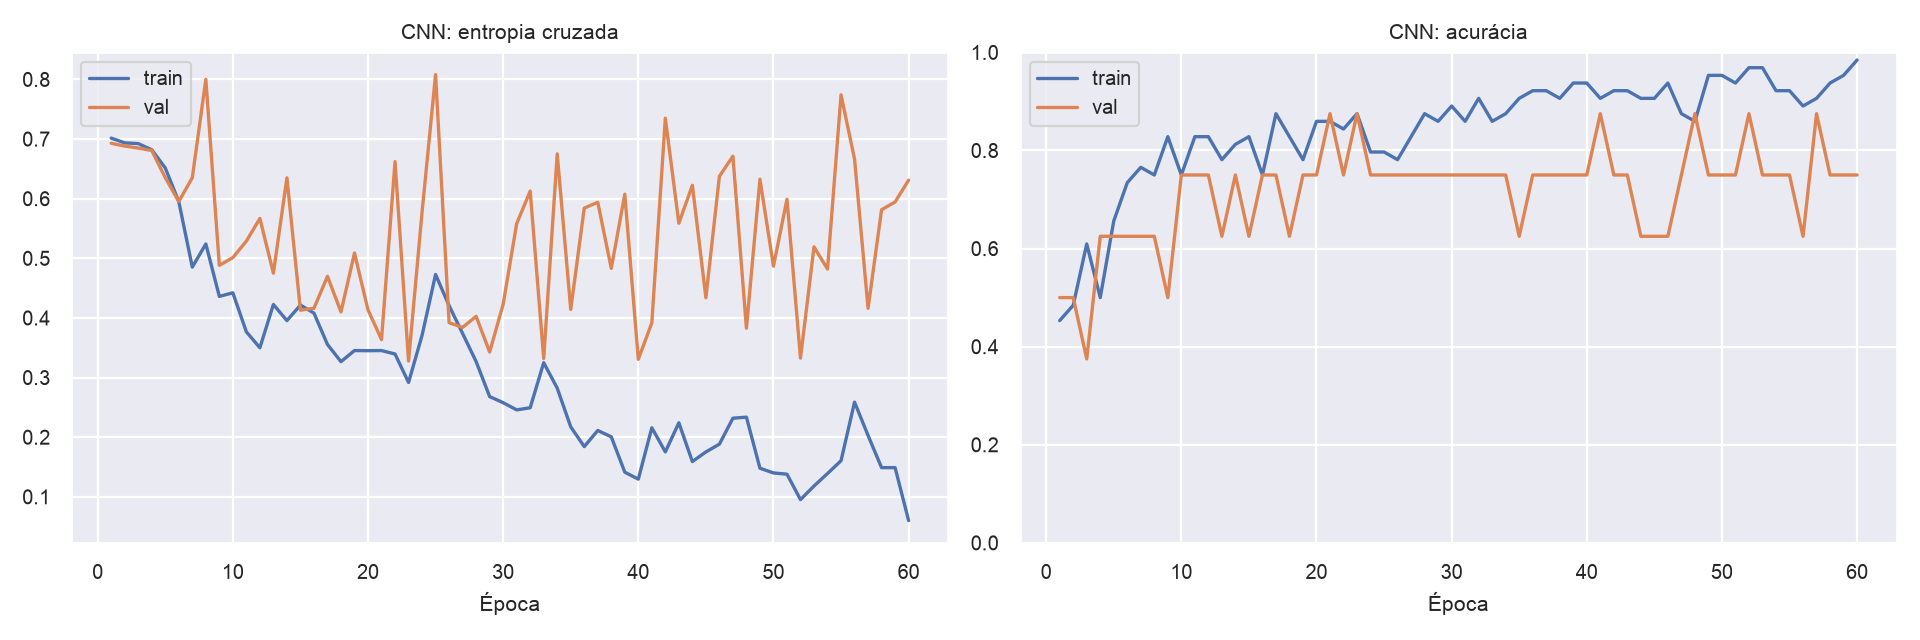

In [10]:
cnn_meta = train_cnn(DATA, RESULTS, epochs=60, device=DEVICE)
training_records.append(cnn_meta)
display(cnn_meta)
cnn_history = pd.read_csv(RESULTS/'cnn/history.csv')
display(cnn_history.tail())
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,2,figsize=(12,4))
for split in ['train','val']:
    axes[0].plot(cnn_history.epoch, cnn_history[f'{split}_loss'], label=split)
    axes[1].plot(cnn_history.epoch, cnn_history[f'{split}_accuracy'], label=split)
axes[0].set(title='CNN: entropia cruzada', xlabel='Época')
axes[1].set(title='CNN: acurácia', xlabel='Época', ylim=(0,1))
for ax in axes: ax.legend()
plt.tight_layout()
fig.savefig(RESULTS/'cnn/learning_curves.png', dpi=160)
plt.close(fig)
display(DisplayImage(filename=str(RESULTS/'cnn/learning_curves.png')))

## 11. Teste final — detecção e classificação

Agora aplicamos os pesos fixados às **oito imagens de teste**, sem novo ajuste.
Para comparar as três abordagens, derivamos uma classificação por imagem de
cada detector: classe da caixa mais confiante entre as duas classes-alvo com
confiança ≥0,25. Sem detecção, o detector se abstém; a abstenção é erro.
A CNN sempre decide entre as duas classes. Medimos acurácia, taxa de erro,
macro F1, matriz de confusão e mediana da latência.

Latência: entrada RGB já decodificada, lote 1, aquecimento com duas imagens,
três repetições por foto, pré-processamento e pós-processamento incluídos.
Leitura do disco e carregamento dos pesos ficam fora. Resoluções diferentes
avaliam nossas configurações operacionais; não isolam a eficiência da arquitetura.
Não usamos o tempo forward de `val.py` para comparar diretamente com a CNN.

In [11]:
classification_records = []
for meta in [meta30, meta60, baseline]:
    is_standard = meta['model'] == 'yolo_padrao'
    detection_records.append(evaluate_detection(DATA, REPO, RESULTS, meta['weights'],
                                              meta['model'], 'test', standard=is_standard, device=DEVICE))
    records, pictures = yolo_image_predictions(DATA, REPO, meta['weights'],
                                             standard=is_standard, device=DEVICE)
    classification_records.append(save_evidence(RESULTS, meta['model'], records, pictures))
cnn_records = cnn_predictions(DATA, RESULTS, device=DEVICE)
classification_records.append(save_evidence(RESULTS, 'cnn_zero', cnn_records))
display(pd.DataFrame(detection_records))
display(pd.DataFrame(classification_records).drop(columns='confusion_matrix'))

YOLOv5 🚀 v7.0-0-g915bbf2 Python-3.12.14 torch-2.5.1 CPU



/Users/ryanpablo/Documents/Codex/2026-09-30/files-pasted-by-the-user-introdu/work/yolov5/models/experimental.py:79: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torc

Model summary: 157 layers, 1761871 parameters, 0 gradients, 4.1 GFLOPs


test: Scanning /Users/ryanpablo/Documents/Codex/2026-09-30/files-pasted-by-the-user-introdu/outputs/FarmTech_Fase6/dataset/labels/test...:   0%|          | 0/8 00:00

/Users/ryanpablo/Documents/Codex/2026-09-30/files-pasted-by-the-user-introdu/work/yolov5/utils/general.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
/Users/ryanpablo/Documents/Codex/2026-09-30/files-pasted-by-the-user-introdu/work/yolov5/utils/general.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
/Users/ryanpablo/Documents/Codex/2026-09-30/files-pasted-by-the-user-introdu/work/yolov5/utils/general.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resou

...

/Users/ryanpablo/Documents/Codex/2026-09-30/files-pasted-by-the-user-introdu/work/yolov5/models/common.py:702: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


/Users/ryanpablo/Documents/Codex/2026-09-30/files-pasted-by-the-user-introdu/work/yolov5/models/common.py:702: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/Users/ryanpablo/Documents/Codex/2026-09-30/files-pasted-by-the-user-introdu/work/yolov5/models/common.py:702: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/Users/ryanpablo/Documents/Codex/2026-09-30/files-pasted-by-the-user-introdu/work/yolov5/models/common.py:702: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/Users/ryanpablo/Documents/Codex/2026-09-30/files-pasted-by-the-user-introdu/work/yolov5/models/common.py:702: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocas

/Users/ryanpablo/Documents/Codex/2026-09-30/files-pasted-by-the-user-introdu/work/yolov5/models/common.py:702: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/Users/ryanpablo/Documents/Codex/2026-09-30/files-pasted-by-the-user-introdu/work/yolov5/models/common.py:702: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/Users/ryanpablo/Documents/Codex/2026-09-30/files-pasted-by-the-user-introdu/work/yolov5/models/common.py:702: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


,model,split,precision,recall,map50,map50_95,inference_forward_ms,annotation_source
0,yolo_30ep,val,0.208498,0.350000,0.253381,0.093323,22.789478,Make Sense AI
1,yolo_60ep,val,0.436382,0.575000,0.495207,0.259320,10.632694,Make Sense AI
2,yolo_padrao,val,0.926732,0.450000,0.581122,0.424171,19.857377,Make Sense AI
3,yolo_30ep,test,0.201358,0.333333,0.299486,0.090271,14.244497,Make Sense AI
4,yolo_60ep,test,0.312978,0.266667,0.281179,0.130668,11.100084,Make Sense AI
5,yolo_padrao,test,0.440500,0.439608,0.519803,0.298036,20.826757,Make Sense AI


,model,accuracy,error_rate,macro_f1,abstentions,latency_median_ms,n_images
0,yolo_30ep,0.00,1.00,0.000000,8,12.272771,8
1,yolo_60ep,0.75,0.25,0.803571,1,12.341230,8
2,yolo_padrao,0.75,0.25,0.857143,2,11.984479,8
3,cnn_zero,1.00,0.00,1.000000,0,5.700812,8


## 12. Evidências visuais — todas as imagens de teste

As figuras mostram **predições reais do checkpoint selecionado**. Uma imagem sem
caixa é exibida mesmo assim, sem ocultar falhas. Os arquivos individuais são
salvos para o vídeo e para os prints do repositório.

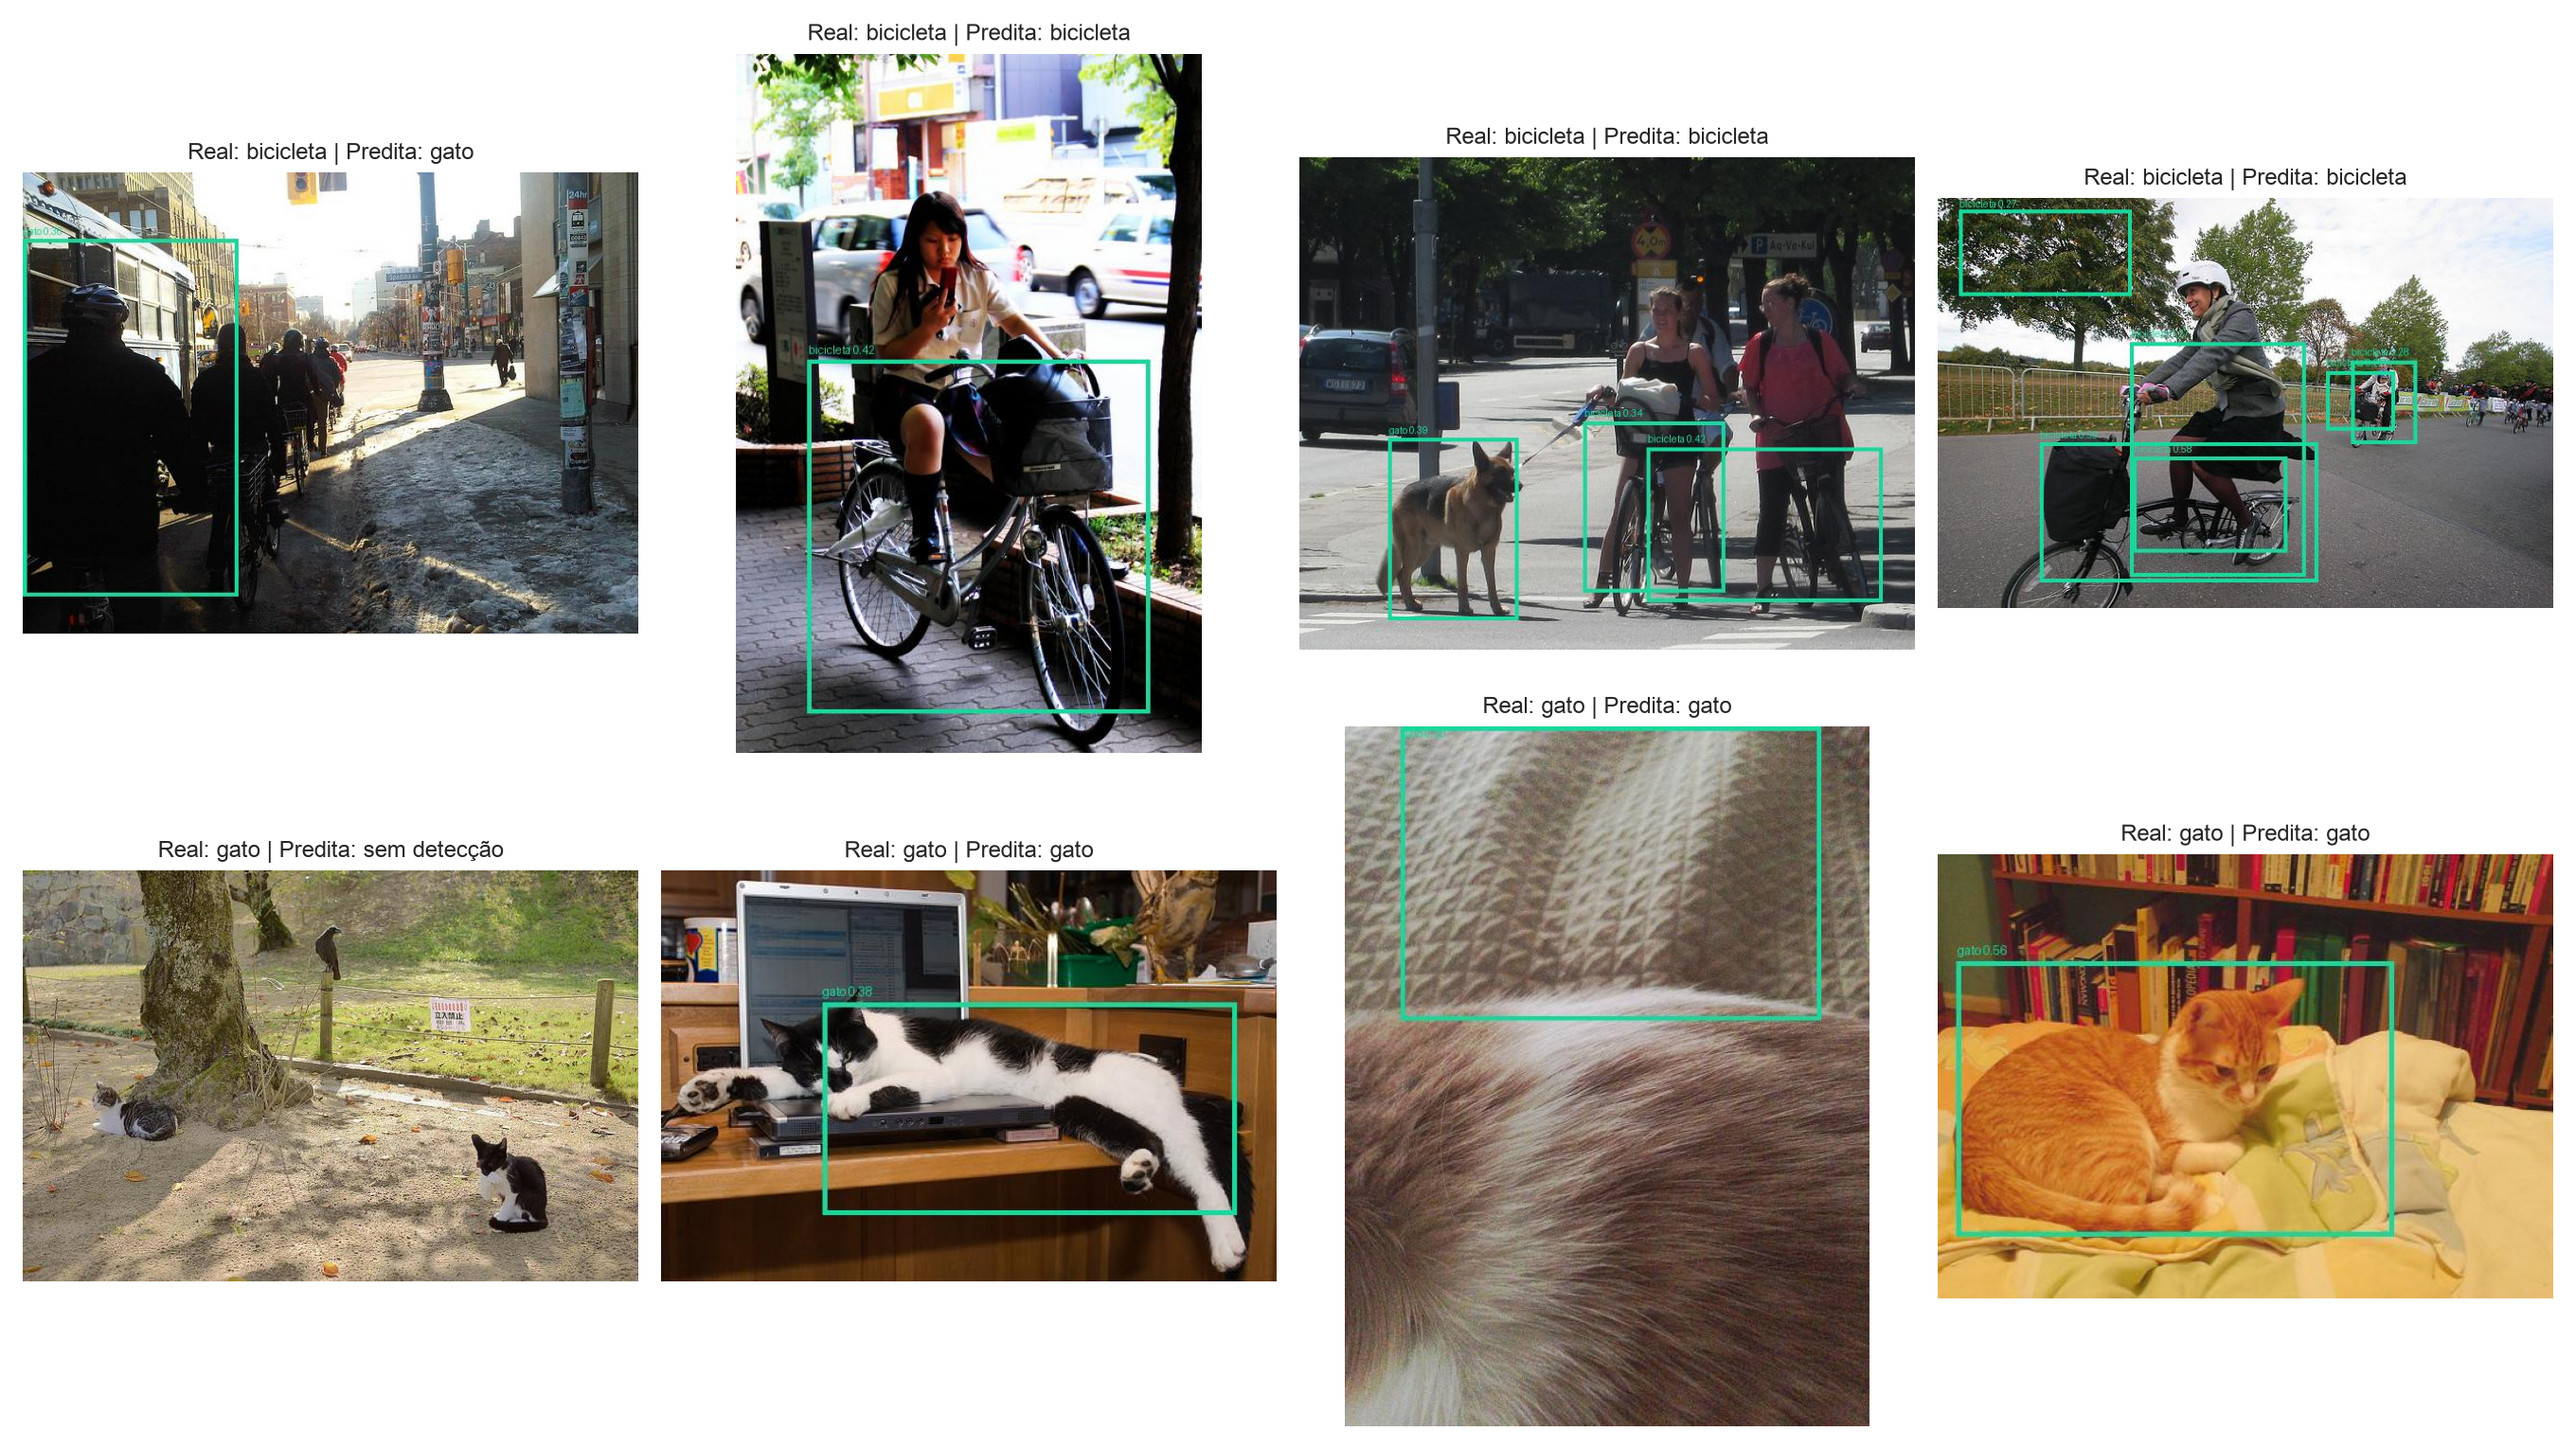

In [12]:
test_rows = manifest[manifest.split=='test']
fig, axes = plt.subplots(2,4,figsize=(16,9))
predictions = pd.read_csv(RESULTS/f'predictions/{selected_model}/predictions.csv').set_index('filename')
for ax, row in zip(axes.flat, test_rows.itertuples()):
    ax.imshow(Image.open(RESULTS/f'predictions/{selected_model}'/row.filename))
    predicted = int(predictions.loc[row.filename,'predicted'])
    pred_name = NAMES[predicted] if predicted>=0 else 'sem detecção'
    ax.set_title(f'Real: {row.classe} | Predita: {pred_name}',fontsize=10)
    ax.axis('off')
plt.tight_layout()
fig.savefig(RESULTS/'test_predictions_grid.png', dpi=170)
plt.close(fig)
display(DisplayImage(filename=str(RESULTS/'test_predictions_grid.png')))

## 13. Comparação crítica e conclusões calculadas

As conclusões numéricas abaixo são construídas a partir dos CSVs/JSONs produzidos
nesta execução. O texto indica se 60 épocas melhoraram ou pioraram a validação,
registra a seleção e apresenta as limitações. Os valores são mostrados em fração
de 0 a 1, salvo os tempos. Não reutilizamos números de exemplos ou benchmarks.

# Resultados da execução — FarmTech Fase 6

## Protocolo
80 imagens: 40 bicicletas e 40 gatos; 64 treino, 8 validação e 8 teste.
YOLOv5n v7.0: duas inicializações iguais, 30 e 60 épocas, imagens 224 px,
batch 4 e semente 42. CNN do zero: 60 épocas, imagens 160 px.
Seleção dos pesos por validação. O teste é usado apenas para avaliação final.

## Detecção
| model       | split   |   precision |   recall |   map50 |   map50_95 |   inference_forward_ms | annotation_source   |
|:------------|:--------|------------:|---------:|--------:|-----------:|-----------------------:|:--------------------|
| yolo_30ep   | val     |      0.2085 |   0.35   |  0.2534 |     0.0933 |                22.7895 | Make Sense AI       |
| yolo_60ep   | val     |      0.4364 |   0.575  |  0.4952 |     0.2593 |                10.6327 | Make Sense AI       |
| yolo_padrao | val     |      0.9267 |   0.45   |  0.5811 |     0.4242 |                19.8574 | Make Sense AI       |
| yolo_30ep   | test    |      0.2014 |   0.3333 |  0.2995 |     0.0903 |                14.2445 | Make Sense AI       |
| yolo_60ep   | test    |      0.313  |   0.2667 |  0.2812 |     0.1307 |                11.1001 | Make Sense AI       |
| yolo_padrao | test    |      0.4405 |   0.4396 |  0.5198 |     0.298  |                20.8268 | Make Sense AI       |

A passagem de 30 para 60 épocas **aumentou** a mAP50–95 de validação
em +0.1660. A configuração selecionada pela validação é **yolo_60ep**.
Mais épocas não garantem desempenho melhor: compare as curvas de perda,
o pico da mAP e a época do checkpoint escolhido. Perdas de box/obj/cls
são acompanhadas no treino; não são percentuais de erro e não são
comparáveis diretamente à entropia cruzada da CNN.

No teste, a YOLO padrão obteve mAP50–95 **0.2980**,
enquanto a configuração customizada selecionada obteve
**0.1307**. Nesta amostra, customizar a rede
não assegurou melhor localização do que utilizar pesos padrão. O detector pode
acertar a classe da foto e, ainda assim, perder instâncias ou detectar caixas falsas.

## Classificação comum às abordagens
| model       |   accuracy |   error_rate |   macro_f1 |   abstentions |   latency_median_ms |   n_images |
|:------------|-----------:|-------------:|-----------:|--------------:|--------------------:|-----------:|
| yolo_30ep   |       0    |         1    |     0      |             8 |             12.2728 |          8 |
| yolo_60ep   |       0.75 |         0.25 |     0.8036 |             1 |             12.3412 |          8 |
| yolo_padrao |       0.75 |         0.25 |     0.8571 |             2 |             11.9845 |          8 |
| cnn_zero    |       1    |         0    |     1      |             0 |              5.7008 |          8 |

O detector recebe como predição da imagem a classe da caixa mais confiante
entre as duas classes-alvo, com confiança mínima 0,25. Ausência de caixa
é abstenção, contada como erro. A CNN fornece diretamente uma das duas classes.
Esta comparação avalia a identificação por imagem; somente YOLO localiza objetos.

A CNN acertou **8/8** imagens;
o detector customizado escolhido acertou **6/8**.
O treino de 30 épocas teve **8 abstenções**
com limiar 0,25. A mAP usa confiança mínima 0,001 para construir a curva PR;
portanto uma mAP acima de zero pode coexistir com várias abstenções no limiar
operacional. Mantivemos 0,25 fixo, sem ajustá-lo depois de observar o teste.

## Custo de treinamento
| model       |   epochs |   train_seconds | device   |   best_epoch |
|:------------|---------:|----------------:|:---------|-------------:|
| yolo_30ep   |       30 |         140.345 | cpu      |           29 |
| yolo_60ep   |       60 |         260.671 | cpu      |           44 |
| yolo_padrao |        0 |           0     | cpu      |          nan |
| cnn_zero    |       60 |          72.163 | cpu      |           23 |

O baseline pré-treinado não é customizado: seu custo de treinamento **neste projeto**
é zero, mas isso não representa o custo de seu pré-treinamento original.
Latência foi medida após aquecimento, com lote 1, três repetições por imagem,
no mesmo dispositivo, incluindo pré-processamento, decisão e NMS quando aplicável.
Decodificação do arquivo e carregamento dos pesos ficam fora desse intervalo.
As resoluções de entrada diferem (224/160 px), portanto a comparação representa
as configurações implantadas, não a eficiência intrínseca de cada arquitetura.
Os detectores de 30/60 épocas têm a mesma arquitetura: diferenças de latência
podem refletir o número de propostas após NMS, cache e carga concorrente do
computador. Três repetições por foto são poucas; as medições não constituem
benchmark dedicado e não justificam afirmar superioridade geral de velocidade.

## Integração e limitações
YOLO padrão exige pouco esforço quando as classes já existem no COCO; a versão
customizada acrescenta coleta, revisão de caixas e treino, mas adapta a detecção
ao escopo do cliente. A CNN tem arquitetura simples e pipeline de rótulo por imagem,
porém exige implementar treino e pré-processamento e não produz caixas.
Somente 8 imagens de teste: cada acerto altera a acurácia em 12,5 pontos percentuais.
Não há evidência suficiente para afirmar superioridade geral ou uso em produção.
O filtro de tamanho e a exclusão de imagens com ambas as classes tornam o cenário
mais simples; não avaliamos cenas mistas, negativos, vídeos ou mudança de domínio.
As imagens vêm de COCO val2017, benchmark conhecido; checkpoints pré-treinados
podem ter sido selecionados usando esse benchmark. Não tratamos esse teste como
avaliação externa totalmente independente. A CNN do zero não tem esse pré-treino.
Hashes detectam cópias exatas, mas não garantem ausência de cenas semelhantes.
Para o cliente, ampliar a base com fotos próprias, dividir por local/sessão e
avaliar negativos e cenas mistas é o próximo passo antes de implantação.

## Evidências
`comparison.png`, `confusion_matrices.png`, `predictions/` (as oito imagens por
detector), CSVs de resultados, logs, históricos e checkpoints registram a execução.
Fonte das anotações aparece explicitamente na tabela de detecção.


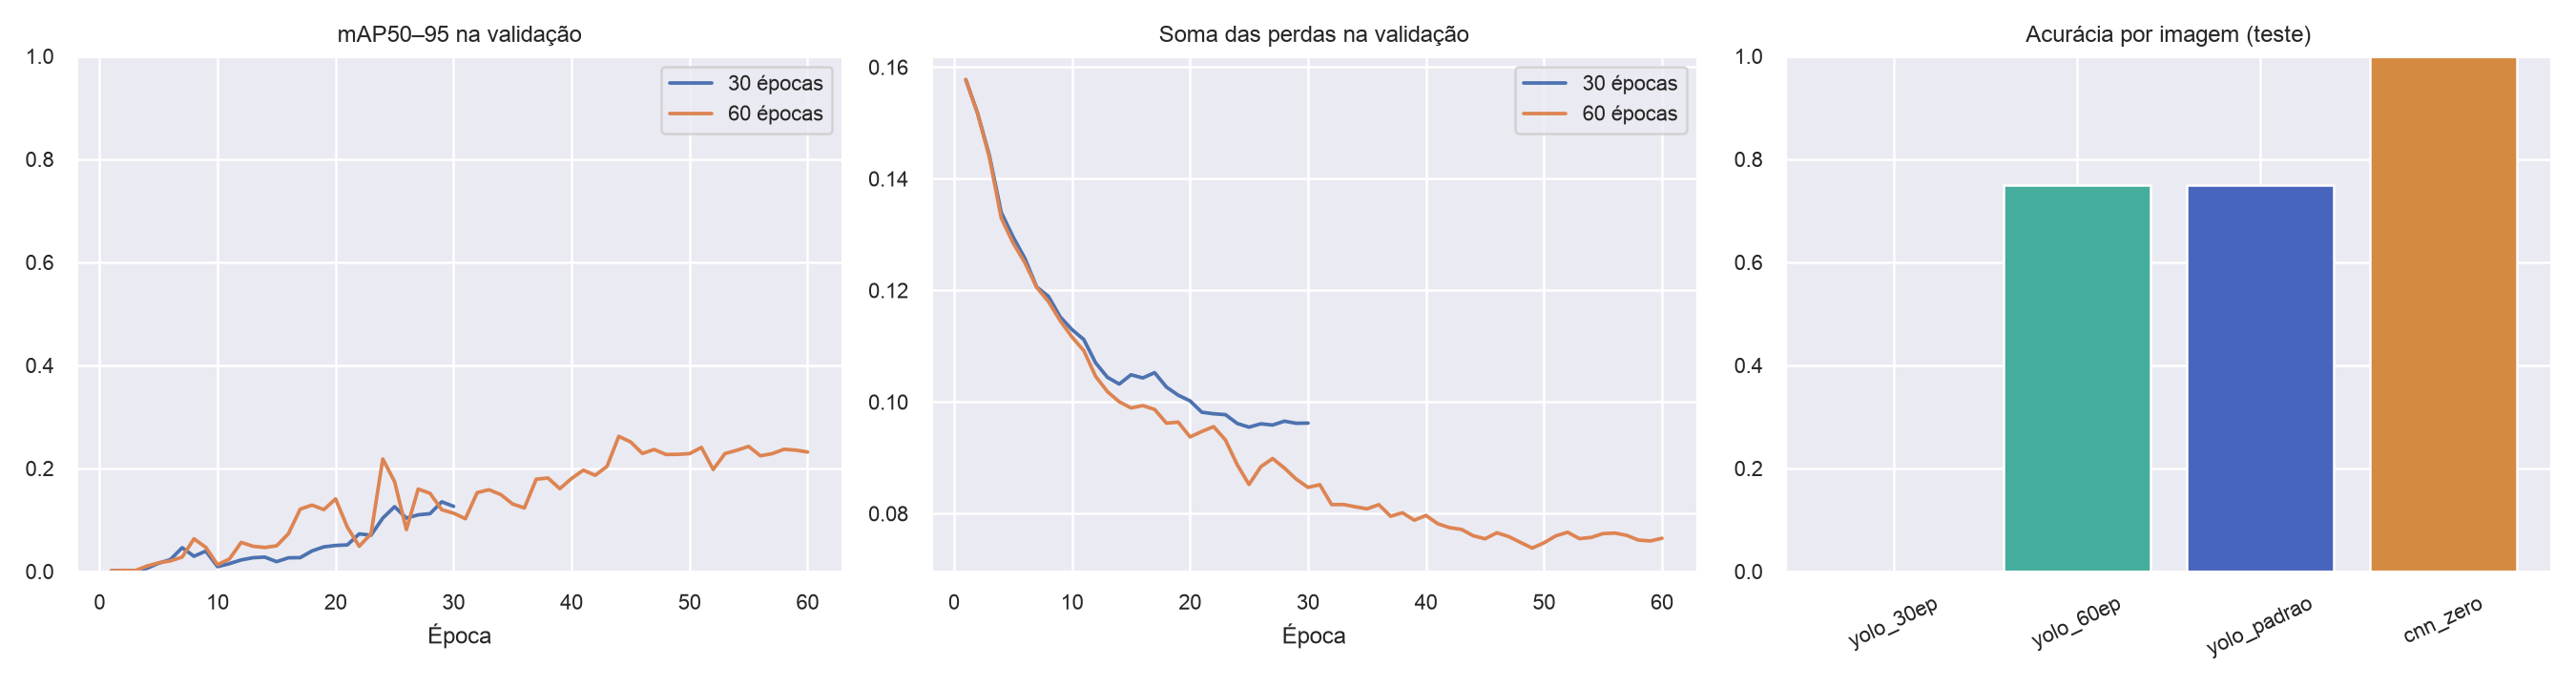

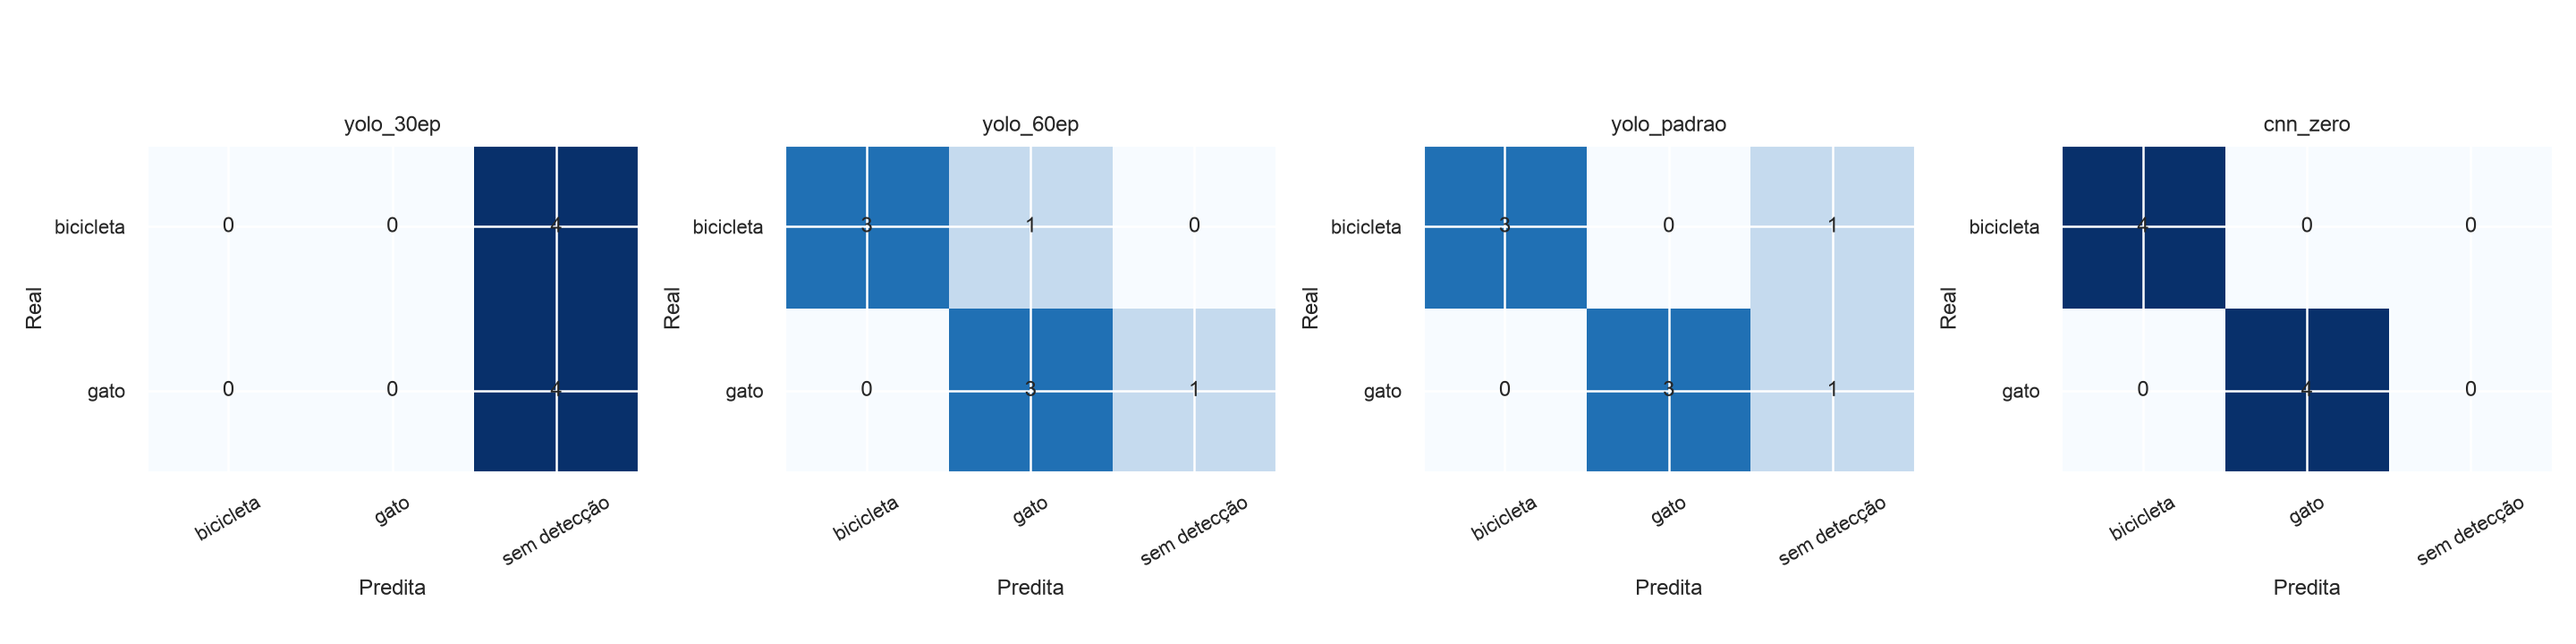

In [13]:
report = create_report(RESULTS, detection_records, classification_records, training_records)
display(Markdown(report))
display(DisplayImage(filename=str(RESULTS/'comparison.png')))
display(DisplayImage(filename=str(RESULTS/'confusion_matrices.png')))

## 14. Entrega e limites do estudo

**Integração:** YOLO padrão tem menor esforço quando as classes já existem;
YOLO customizada requer caixas e treinamento, mas permite adaptação ao cliente;
CNN é simples para classificar fotos, porém não atende sozinha ao requisito de
localização. O experimento não garante que mais épocas produzam melhor rede.

**Validade:** 8 fotos de validação e 8 de teste trazem grande incerteza. Um acerto
equivale a 12,5 pontos percentuais na acurácia de teste. Não estimamos desempenho
em produção com essa amostra; faltam fotos próprias, classes negativas, cenas
mistas e avaliação por sessão/local. Também há influência do pré-treinamento COCO.
Estes limites são parte do resultado, não falhas escondidas.

**Entregáveis gerados:** históricos de treino, pesos, tabelas comparativas,
matrizes de confusão, gráficos, relatório e oito prints de teste por detector.
O notebook precisa permanecer com saídas salvas no GitHub. O README aponta
para este documento e para o vídeo de até cinco minutos. Não faça commits após
o prazo de entrega; registre o commit final e os links no portal da FIAP.

As opções “Ir Além” são extras e não integram o escopo obrigatório deste notebook.

## Referências

- YOLOv5 v7.0 (código oficial): https://github.com/ultralytics/yolov5/tree/v7.0
- Treinamento customizado: https://docs.ultralytics.com/yolov5/tutorials/train_custom_data/
- COCO: https://cocodataset.org/#download
- Make Sense AI: https://www.makesense.ai/
- PyTorch (CNN e treino): https://pytorch.org/docs/stable/index.html
- Métricas e seleção do YOLOv5: `val.py`, `train.py` e `utils/metrics.py` do commit fixado.

## Créditos e autoria

Código e documentação preparados com assistência de IA. Os integrantes devem
conferir os resultados, compreender as decisões e preencher sua identificação.
Fotos e anotações de origem: COCO, com atribuição por imagem no manifesto.
YOLOv5 v7.0: Ultralytics, licença GPL-3.0.

In [14]:
# Confirma que artefatos essenciais existem antes de considerar a execução concluída.
required_artifacts = ['detection_comparison.csv','classification_comparison.csv',
                      'training_comparison.csv','RELATORIO_RESULTADOS.md',
                      'comparison.png','test_predictions_grid.png','confusion_matrices.png']
for filename in required_artifacts:
    assert (RESULTS/filename).exists(), f'Falta: {filename}'
assert len(history30)==30 and len(history60)==60 and len(cnn_history)==60
print('Execução concluída: 30/60 épocas YOLO, 60 épocas CNN, avaliações e evidências salvas.')
print('Rotulação Make Sense:', (DATA/'annotation_status.json').exists())
print('Identificação dos integrantes e links públicos devem ser preenchidos antes da entrega.')

Execução concluída: 30/60 épocas YOLO, 60 épocas CNN, avaliações e evidências salvas.
Rotulação Make Sense: True
Identificação dos integrantes e links públicos devem ser preenchidos antes da entrega.
